# Phase 1 - Heart Disease Prediction

**Course:** SWE485 (Selected Topics in Software Engineering)
**Phase:** 1 (Supervised Learning & Model Development)
**Dataset:** Heart Disease Dataset (Kaggle – Preprocessed Version)

This notebook covers:
• Next Steps for Phase 2 Integration  ? (عشان ماننساها لانها مكتوبة)

# The Notebook Overview


## 1. Model Selection & Rationale
In this section, we will justify the choice of each model based on the characteristics of our dataset and the problem type, as well as the strengths and weaknesses of the models in addressing the task of heart disease prediction.

## 2. Implementation & Training
In this section , we will describe how each model was implemented and trained. Here, we can see the common procedures applied to all three models.

### 2.1 Train / Test Split

#### **Why do we split at all?**
A machine learning model learns patterns from data. If we evaluate it on the same data it
learned from, it will look like it performs perfectly, but that tells us nothing about how
it handles new, unseen patients. As scikit-learn's official documentation states, learning
the parameters of a model and testing it on the same data is a methodological mistake: a
model that simply repeats the labels it has seen would score perfectly but fail on any new
data (scikit-learn, 2024). We therefore need a separate test set that the model never sees
during training to get an honest measure of real-world performance.

Additionally, our approach involves an exhaustive hyperparameter search over hundreds of
combinations to find the best model configuration. The data used to select that winning
combination must never include the test set, otherwise the selection process would be
indirectly influenced by the samples we intend to evaluate on, compromising the fairness
of the final result. The hyperparameter search process is explained in detail in Section 3.

#### **Why 80% training and 20% testing?**
With 917 samples, we need to give the model enough data to learn meaningful patterns while
still reserving enough samples to evaluate it fairly. An 80/20 split gives ~733 samples for
training and ~183 for testing. Empirical studies confirm that 80/20 provides a good balance
for moderate-sized datasets (Gholamy et al., 2018).

A known limitation of holdout splitting is that the test set may not perfectly represent
the full population, particularly when the dataset is small (Varoquaux et al., 2023).
We mitigate this in two ways: first, we use stratified splitting, which guarantees the
test set preserves the exact class ratio of the full dataset; second, we independently
run cross-validation on the training set and report its metrics alongside the test set
results. If both sets of metrics are in close agreement, that is empirical evidence that
the test set is representative. The printed evaluation results in Section 4 confirm this.

#### **Our approach: 80/20 split first, then k-fold inside the training set only**
Some resources and tutorials apply k-fold directly to the full dataset without holding out
a test set first, passing the entire X and y into cross_val_score and reporting the mean
score as the final result (DataCamp, 2024). This simplified approach is common in
introductory tutorials because it is easier to demonstrate.

However, for our project we deliberately follow a more rigorous approach. We first hold out
20% of the data as a completely untouched test set, then apply 5-fold cross-validation
exclusively within the remaining 80% training set. This is the workflow explicitly
recommended by both scikit-learn (2024) and Machine Learning Mastery (2021).


Machine Learning Mastery (2021) further demonstrates this exact two-step workflow:
first perform train/test split, then apply k-fold cross-validation on the training set
only to select and tune the model, and finally evaluate on the held-out test set to confirm
generalisation performance.

In summary, each component of our approach serves a distinct and necessary purpose:

- **K-fold on the 80% training set** → tunes hyperparameters and verifies the model is
  stable and consistent across different subsets of training data
- **The held-out 20% test set** → provides the final unbiased performance report on data
  the model has never touched at any stage of training or tuning

In a critical medical application, K-fold alone is not
sufficient because it cannot guarantee a truly isolated evaluation set.

#### **Why are we saving the split indices?**
We train three different models in this project. For the comparison between them to be
fair, all three models must be evaluated on exactly the same test samples and trained on
exactly the same training samples. If each model used a different random split, any
difference in performance could be due to the split rather than the model itself. By saving
the split indices once and loading them in every cells notebook, we guarantee a completely
fair comparison across all models.


### 2.2 Hyperparameter Tuning Process & Results

#### **What is hyperparameter tuning?**
Hyperparameters are settings that control how the model is built. Unlike regular parameters
(which the model learns from data automatically), hyperparameters must be set by us before
training begins. Choosing the wrong values can lead to a model that is too simple to learn
patterns (underfitting) or too complex and memorises the training data (overfitting). Tuning
finds the best combination for our specific dataset.

#### **Why GridSearchCV with k-fold inside?**
GridSearchCV tries every possible combination of the hyperparameter values we provide. For
each combination, it uses **5-fold cross-validation** to score it, meaning it trains and
validates the model 5 times on different subsets of the training data and averages the score.
This makes the evaluation of each combination reliable and not dependent on a single lucky
or unlucky split. (GeeksforGeeks, 2025).

#### **Why GridSearchCV specifically for our case?**
We chose GridSearchCV because it automatically tries every possible combination of settings and picks the best one, so we do not have to guess. Our list of combinations is small enough (288) that checking all of them only takes a few minutes, making this practical. In a medical setting where prediction accuracy directly affects patient outcomes, relying on default settings or guesswork is not acceptable. GridSearchCV removes that risk by being exhaustive and objective. We also apply it consistently across all three models in this project, so when we compare their results, we know any difference in performance is due to the model itself and not how it was tuned.


#### **Why ROC-AUC was used as the scoring metric instead of Recall?**
Optimising for Recall alone introduces a risk: the model may learn to predict
disease for almost every patient just to maximise the number of true positives,
at the cost of an unacceptably high false alarm rate. ROC-AUC avoids this
problem because it evaluates the model across all possible decision thresholds
rather than a single cutoff, rewarding a model that genuinely separates the
two classes rather than one that simply predicts one class more aggressively.
As stated by Bradley (1997), ROC-AUC is a better measure of classifier
performance in cases where class distributions are roughly equal. Since our
dataset is balanced, this makes ROC-AUC the more appropriate and balanced
scoring metric for our model.

> GeeksforGeeks. (2025). *Performing feature selection with GridSearchCV in sklearn.*
> https://www.geeksforgeeks.org/machine-learning/performing-feature-selection-with-gridsearchcv-in-sklearn/

> Bradley, A.P. (1997). *The use of the area under the ROC curve in the evaluation
> of machine learning algorithms.* Pattern Recognition, 30(7), 1145–1159.
> https://doi.org/10.1016/S0031-3203(96)00142-2

## 3. Comprehensive Evaluation
In this section, we will evaluate the performance of the models based on several key metrics and visualizations. The evaluation will be conducted based on the following:

#### Two-stage evaluation approach:

**Stage 1 — 5-Fold Cross-Validation (on training set):**
Checks whether the tuned model is stable and consistent. A model that performs well in cross-validation but poorly on the test set is overfitting. A low standard deviation across folds means the model behaves consistently regardless of which subset of training data it sees.

**Stage 2 — Final evaluation on the held-out test set:**
The test set was locked away before any training or tuning began. The model has never seen these samples. This gives the final, unbiased answer to: *"how does this model perform on a completely new patient?"*

Both stages are necessary. Cross-validation alone is not enough because every sample in it was used for training at some point. The test set alone is not enough because a single split might be lucky or unlucky.

The following measures will be used:

- **Accuracy:** The percentage of correct predictions made by the model.
Since the dataset is balanced, accuracy is a reliable and meaningful metric
as both classes are equally represented.

- **Precision:** The proportion of true positive predictions relative to
the total predicted positives.

- **Recall:** The proportion of true positive predictions relative to
the total actual positives.

- **Confusion Matrix:** A visualization that shows the true positives,
false positives, true negatives, and false negatives, helping to understand
how well the model classifies each category.

- **ROC-AUC:** For binary classification, this metric evaluates the model's
ability to distinguish between the classes across all possible decision
thresholds.

**Why F1-Score was excluded:**
F1-Score is designed specifically for imbalanced datasets. As stated by
Google's Machine Learning documentation, F1 is "preferable to accuracy for
class-imbalanced datasets" (Google Developers, 2024), which implies that for
balanced datasets, accuracy is already sufficient. This is further supported
by Great Learning (2025), which states that accuracy is "ideal when the
dataset is balanced and false positives and negatives have similar
consequences." Since our dataset is balanced with both classes equally
represented, accuracy provides a complete and reliable picture of overall
model performance, making F1-Score redundant in this context.

> Google Developers. (2024). *Classification: Accuracy, recall, precision,
> and related metrics.* Machine Learning Crash Course.
> https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall

> Great Learning. (2025). *F1 Score in Machine Learning: Formula, Precision
> and Recall.*
> https://www.mygreatlearning.com/blog/f1-score-in-machine-learning/

## 4. Comparative Analysis & Interpretation
In this section, we will compare the performance of all three models based on their evaluation results and interpret their behavior:

**Which model performed best? Why?**
We will identify the best-performing model and explain why it performed better than the others based on the evaluation metrics.

**Analyze misclassifications: patterns, challenging categories**
We will examine the misclassifications made by the models, look for patterns in the mistakes, and identify which categories were more challenging for the models to predict.

**Discuss trade-offs: accuracy vs. interpretability vs. computational cost**
We will discuss the trade-offs between the models in terms of:

Accuracy: How well the model performs.

Interpretability: How easy it is to understand the model’s decisions.

Computational cost: The resources and time required for training and making predictions.

Recommendation: Which model will you use in your final system and why?
Based on the comparative analysis, we will recommend which model should be used in the final system and justify our choice.

---

> Gholamy, A., Kreinovich, V., & Kosheleva, O. (2018). *Why 70/30 or 80/20 relation
> between training and testing sets.* UTEP.
> https://scholarworks.utep.edu/cs_techrep/1209/
>
> scikit-learn. (2024). *Cross-validation: evaluating estimator performance.*
> https://scikit-learn.org/stable/modules/cross_validation.html
>
> Tam, A. (2021). *Training-validation-test split and cross-validation done right.*
> Machine Learning Mastery.
> https://machinelearningmastery.com/training-validation-test-split-and-cross-validation-done-right/
>
> Varoquaux, G., et al. (2023). *A guide to cross-validation for artificial intelligence
> in medical imaging.* Radiology: Artificial Intelligence.
> https://pmc.ncbi.nlm.nih.gov/articles/PMC10388213/
>
> DataCamp. (2024). *A comprehensive guide to K-Fold Cross Validation.*
> https://www.datacamp.com/tutorial/k-fold-cross-validation
>
> GeeksforGeeks. (2025). *Cross validation in machine learning.*
> https://www.geeksforgeeks.org/machine-learning/cross-validation-machine-learning/









# Random Forest



## Section 1. Model Selection & Rationale :

Random Forest is an ensemble learning algorithm that builds multiple decision trees during
training and combines their predictions through majority voting for classification. As IBM (2025)
explains, Random Forest is built on the principle of bagging (Bootstrap Aggregating), where each
tree is trained on a random sample of the data with replacement, which reduces variance and
improves the model's generalization ability.

---

### **Why Random Forest is a Good Fit for Our Data?**

#### i. Dataset Characteristics (Size, Feature Types, and Linearity)

The dataset contains **917 observations** after dropping one invalid RestingBP record. Following
one-hot encoding of categorical features (ChestPainType, RestingECG, ST_Slope, Chol_category), the feature
space expanded to **17 variables**.
With a wider feature space like this, there is a risk that certain dominant variables overshadow
others during model training. Random Forest's random feature subsampling at each split directly
addresses this by considering only a random subset of features at each node, it prevents any
single variable from consistently dominating the splits and ensures that all features, including
the one-hot encoded variables, have an opportunity to contribute to the prediction.

Regarding feature types, the dataset after preprocessing consists entirely of numerical
variables, continuous features (Age, RestingBP, MaxHR, Oldpeak) were normalized, and all
categorical features were encoded into numerical form. Random Forest works well with this fully
numerical structured input, as its tree-splitting mechanism evaluates feature thresholds across
all features uniformly, regardless of their original scale or type.

Regarding linearity, the pair plot analysis confirmed that continuous features do not exhibit
clear linear relationships with each other or with the target variable HeartDisease. IBM (2025)
highlights that Random Forest handles non-linear data effectively, since tree-based splits
recursively partition the feature space and can model complex, irregular decision boundaries that
linear models cannot capture.

---

#### ii. Problem Type (Binary Classification)

Our task is a binary classification problem: predicting whether a patient has heart disease
(HeartDisease = 1) or does not (HeartDisease = 0). The class distribution is relatively balanced
as shown in the pie chart visualization. Random Forest is well-suited to binary classification,
as it outputs a majority vote across all trees for each class, producing stable and reliable
binary predictions. IBM (2025) notes that Random Forest is widely applied in healthcare
classification tasks, directly aligned with our heart disease prediction system, where reliable
and consistent class separation is essential.

---

#### iii. Model Strengths and Weaknesses for Our Specific Problem

**Strengths:**

- **Robustness to outliers:** Our EDA identified outliers in multiple clinical features,
RestingBP contained outliers on the right side, requiring RobustScaler normalization, and
Oldpeak exhibited right skewness with extreme values. Because Random Forest makes decisions
based on feature thresholds rather than distances or magnitudes, it is naturally less affected
by extreme values compared to other models. This is especially important in medical data,
where an unusual value may still represent a real and significant clinical case that should not be
ignored.

- **Feature importance:** Random Forest provides feature importance scores after training,
showing how much each variable contributed to the predictions. IBM (2025) notes this is one
of Random Forest's key advantages, and in a medical system like ours it helps identify which
clinical measurements, such as chest pain type or ST slope, are the most influential in
predicting heart disease.

- **High accuracy on tabular data:** IBM (2025) notes that Random Forest is known for
producing highly accurate results on structured tabular datasets, which is essential for our
system where reliable medical prediction is critical.

**Weaknesses:**

- **Computational cost:** Based on GeeksforGeeks (2025), since Random Forest builds many trees instead of
just one, it requires more memory and processing time, especially when tuning hyperparameters to find the
best model settings.

- **Reduced interpretability:** Although feature importance scores are available, GeeksforGeeks (2025) have
stated that it is difficult to trace exactly how a single prediction was made, since the final result comes
from combining hundreds of trees rather than following one clear decision path.

Despite these weaknesses, Random Forest remains the most suitable choice for our project. It
handles our expanded 17-feature dataset efficiently, captures the non-linear relationships
observed in the EDA, tolerates the clinical outliers identified during preprocessing, and is
well-established in healthcare classification tasks, all of which directly match the
characteristics and goals of our heart disease prediction system.

---

### References

> IBM. (2025). *What is random forest?* IBM Think.
> https://www.ibm.com/think/topics/random-forest
>
> GeeksforGeeks. (2025). *Random forest algorithm in machine learning.*
> https://www.geeksforgeeks.org/machine-learning/random-forest-algorithm-in-machine-learning/

## Section 2. Implementation & Training

### Import Libraries

In [38]:
import subprocess
subprocess.run(["pip", "install", "seaborn"], check=True)
#Standard libraries
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
warnings.filterwarnings('ignore')

#  Model
from sklearn.ensemble import RandomForestClassifier

#  Splitting & cross-validation
from sklearn.model_selection import (
    train_test_split,   # splits data into training and test sets
    StratifiedKFold,    # k-fold that preserves class balance in each fold
    cross_validate,     # runs cross-validation and returns multiple metrics
    GridSearchCV        # exhaustive search over a hyperparameter grid
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,     # proportion of correct predictions
    precision_score,    # of all predicted positives, how many are truly positive
    recall_score,       # of all actual positives, how many were correctly predicted
    confusion_matrix,   # table showing TP, TN, FP, FN counts
    roc_auc_score,      # area under the ROC curve
    roc_curve           # false positive rate vs true positive rate at all thresholds
)

# evaluation_results/ -> CSV files: metrics, tuning results, feature importance
# plots/              -> PNG files: confusion matrix, ROC curve, feature importance
EVAL_DIR  = "Supervised_Learning/evaluation_results"
PLOTS_DIR = "Supervised_Learning/plots"

os.makedirs(EVAL_DIR,  exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# Model name prefix
# Used in every saved file name so outputs are clearly labelled per model
MODEL_NAME = "random_forest"

print("Libraries imported successfully.")
print(f"Evaluation results → {EVAL_DIR}")
print(f"Plots              → {PLOTS_DIR}")

Libraries imported successfully.
Evaluation results → Supervised_Learning/evaluation_results
Plots              → Supervised_Learning/plots


### Load Preprocessed Dataset

In [39]:
# Load the preprocessed dataset
# This CSV was produced by the EDA notebook — it contains cleaned, encoded,
# and normalised features ready for modeling. No further preprocessing is needed.
# Shape: 917 rows × 21 columns (20 features + 1 target column)
DATA_PATH = "Dataset/preprocessed_heart_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 917 rows x 21 columns


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,...,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Chol_category_Desirable,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,1.383339,0,-0.400000,0,0,1,...,0,0,1,0,0,0,1,0,0,1
1,-0.478057,0,1.5,0,0.754736,0,0.266667,1,0,0,...,0,0,1,0,0,1,0,1,0,0
2,-1.750256,1,0.0,0,-1.523953,0,-0.400000,0,0,1,...,0,0,0,1,0,0,1,0,0,1
3,-0.584074,0,0.4,0,-1.131075,1,0.600000,1,1,0,...,0,0,1,0,0,1,0,0,1,0
4,0.052026,1,1.0,0,-0.581047,0,-0.400000,0,0,0,...,0,0,1,0,0,0,1,1,0,0


### Separate Features and Target

In [40]:
# Separate input features from the target variable
# X -> all feature columns (what the model uses to make predictions)
# y -> the target column   (what the model is trying to predict)
TARGET = "HeartDisease"   # 0 = No Disease, 1 = Heart Disease

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features (X): {X.shape[1]} columns")
print(f"\nTarget (y) distribution:")
print(y.value_counts().rename({0: 'No Disease (0)', 1: 'Heart Disease (1)'}))

Features (X): 20 columns

Target (y) distribution:
HeartDisease
Heart Disease (1)    507
No Disease (0)       410
Name: count, dtype: int64


In [41]:
# Create or load the 80/20 train/test split
# This cell implements the first and most critical step of our methodology:
# locking away 20% of the data before any training or tuning begins.
#
# IMPORTANT: This split is created ONCE and shared across all three models.
# If each model used a different split, performance differences could be due
# to the split rather than the model — making comparison unfair.
# Saving and loading the same indices guarantees a completely fair comparison.
SPLIT_PATH = "split_indices.pkl"

if not os.path.exists(SPLIT_PATH):
    # Create the split for the first time
    # stratify=y   → preserves the class ratio (proportion of 0s and 1s)
    #                in both the training and test sets
    # random_state → fixes the random seed so the split is reproducible
    #                running this cell again always produces the same split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    # Save the indices (row positions) of training and test samples
    # We save indices rather than the actual data so any model can
    # reconstruct the exact same split from any version of the dataset
    split_indices = {
        "train_indices": X_train.index.tolist(),
        "test_indices" : X_test.index.tolist()
    }
    with open(SPLIT_PATH, "wb") as f:
        pickle.dump(split_indices, f)

    print("Split created and saved to split_indices.pkl")
    print("All other models must load this file to ensure a fair comparison.")

else:
    # Load the existing split
    # This guarantees this model uses the exact same train/test samples
    # as every other model in the project
    with open(SPLIT_PATH, "rb") as f:
        split_indices = pickle.load(f)

    X_train = X.iloc[split_indices["train_indices"]]
    X_test  = X.iloc[split_indices["test_indices"]]
    y_train = y.iloc[split_indices["train_indices"]]
    y_test  = y.iloc[split_indices["test_indices"]]

    print("Existing split loaded from split_indices.pkl")
    print("This model uses the exact same train/test samples as all other models.")

# Confirm split sizes and class balance
print(f"\nTraining set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))
print(f"\nClass distribution in test set:")
print(y_test.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))

Existing split loaded from split_indices.pkl
This model uses the exact same train/test samples as all other models.

Training set : 733 samples (80%)
Test set     : 184  samples (20%)

Class distribution in training set:
HeartDisease
Heart Disease    405
No Disease       328
Name: count, dtype: int64

Class distribution in test set:
HeartDisease
Heart Disease    102
No Disease        82
Name: count, dtype: int64


#### Random Forest Hyperparameter Selection

Random Forest has a unique set of hyperparameters that directly control how its trees are
built and how they work together as an ensemble. Unlike simpler models, each hyperparameter
affects a different layer of the model, from how many trees vote on the final prediction,
to how deep each tree grows, to how many features each tree considers at each split.
Choosing the right combination is therefore not straightforward, as these settings interact
with each other and their optimal values depend on the specific dataset.

### Why These Specific Hyperparameters Were Selected for Tuning

RandomForestClassifier in scikit-learn has 19 configurable parameters in total. We selected 6
to tune, the ones that directly control the two most important sources of error in any Random
Forest: **overfitting** and **instability**. The remaining 13 were intentionally left at their
defaults, as they either address the same concerns redundantly, require specialist knowledge to
set meaningfully, or are infrastructure parameters that do not affect prediction quality.

**Tuned parameters:**

| Parameter | Why Tuned |
|-----------|-----------|
| `n_estimators` | How many trees to build — More trees reduce prediction variance; the default of 100 is often too conservative for medical datasets |
| `max_depth` | How deep each tree can grow — Unlimited depth causes severe overfitting; constrained to prevent the model from memorising training data |
| `min_samples_split` | Minimum samples needed to split a node — Default of 2 allows splits based on just 2 patients; increased to ensure each split is backed by meaningful evidence |
| `min_samples_leaf` | Minimum samples required at a leaf — Default of 1 allows leaves representing a single patient; increased to ensure every prediction is backed by a group |
| `max_features` | How many features to consider at each split — Controls diversity between trees; tuned to find the right balance between diversity and completeness |


**Parameters not tuned:**

The remaining 14 parameters were excluded because they are either redundant with the above
(`min_weight_fraction_leaf`, `max_leaf_nodes`, `ccp_alpha`), fundamental to the algorithm
and should not be changed (`bootstrap`, `criterion`), diagnostic rather than predictive
(`oob_score`, `warm_start`), infrastructure settings that do not affect model quality
(`n_jobs`, `random_state`, `verbose`) or not applied because the data is balanced (`class_weight`)

> scikit-learn. *RandomForestClassifier*.
> https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


In [42]:
# Step 1: Define the hyperparameter search grid
# param_grid is a menu of options for GridSearchCV to try.
# GridSearchCV will test every possible combination of these values —
# 3×3×4×4×3 = 432 combinations × 5 folds = 2,160 model fits in total.
# Each combination is scored using 5-fold cross-validation on the training set.
# The combination with the highest average ROC-AUC score wins.
param_grid = {
    # Number of decision trees built in the forest
    # More trees reduce variance by averaging out individual tree errors (overfitting noise)
    # 100–300 was too conservative — 500 allows the ensemble to stabilise on a small dataset (917 rows)
    # Diminishing returns beyond 500, so we cap there to keep runtime reasonable
    'n_estimators'     : [200, 300, 500],

    # Maximum depth each tree is allowed to grow
    # Removed 15 and 20 — these still allowed too much depth in the previous iteration
    # contributing to the remaining overfitting gap
    # Keeping only shallow values (5, 8, 10) to further constrain tree complexity
    # and force the model to learn only the strongest, most generalisable patterns
    'max_depth'        : [5, 8, 10],

    # Minimum number of samples a node must have before it is allowed to split further
    # Pushed higher to [15, 20, 25, 30] — each iteration of raising this value has
    # consistently reduced the gap; continuing in the same direction to find the ceiling
    # Higher values force splits to be backed by increasingly strong evidence
    'min_samples_split': [15, 20, 25, 30],

    # Minimum number of samples required at each leaf (terminal node)
    # Pushed higher to [4, 5, 6, 8] — larger leaves mean each prediction is based on
    # more samples, further reducing sensitivity to noise in the training data
    'min_samples_leaf' : [4, 5, 6, 8],

    # Number of features randomly considered at each split point
    # 'sqrt' → uses √17 ≈ 4 features per split (original scikit-learn default, promotes diversity)
    # 'log2' → uses log₂(17) ≈ 4 features per split (similar effect, slightly more aggressive)
    # None   → considers ALL 17 features at every split
    #          on small datasets this often wins because no signal is accidentally excluded;
    #          on large datasets it would be too slow and cause overfitting
    'max_features'     : ['sqrt', 'log2', None],
}

# Step 2: Define the cross-validation strategy
# This tells GridSearchCV HOW to evaluate each combination fairly:
# — Split the 733 training samples into 5 equal folds (~146 samples each)
# — Each fold takes a turn being the validation set exactly once
# — Stratified: every fold preserves the 55/45 class ratio of the full training set
# — shuffle + random_state=42: same fold assignments every run → reproducible results
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Run the exhaustive search
# GridSearchCV ties all three components together:
#   estimator  → the model to train (RandomForestClassifier)
#   param_grid → the combinations to try (432 total)
#   cv         → how to evaluate each combination (5-fold stratified CV)
#   scoring    → what metric to optimise (ROC-AUC)
#
# What happens when .fit() is called:
# 1. For each of 432 combinations → train on 4 folds, validate on 1 fold → 5 times
# 2. Average the 5 ROC-AUC scores for each combination
# 3. Pick the combination with the highest average score
# 4. Retrain that winning combination on ALL 733 training samples from scratch
# 5. Store the final model as grid_search.best_estimator_
#
# n_jobs=-1 → uses all available CPU cores to run fits in parallel
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)

print("Starting hyperparameter search — this may take a few minutes...")
grid_search.fit(X_train, y_train)

print("\nSearch complete.")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")

Starting hyperparameter search — this may take a few minutes...
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Search complete.
Best parameters : {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 15, 'n_estimators': 200}
Best CV ROC-AUC : 0.9299


In [43]:
# Save and display the full hyperparameter search results
# grid_search.cv_results_ contains the score for every combination tried.
# Saving all 432 rows to CSV allows us to review close competitors and
# understand how sensitive performance is to each hyperparameter.
tuning_df   = pd.DataFrame(grid_search.cv_results_)
tuning_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_hyperparameter_tuning.csv")
tuning_df.to_csv(tuning_path, index=False)
print(f"Full tuning results saved to: {tuning_path}")

# Display the top 10 winning configurations ranked by validation ROC-AUC
# mean_validation_score → average ROC-AUC across 5 validation folds
#                         Note: scikit-learn internally calls this 'mean_test_score'
#                         — the word 'test' here refers to the validation fold,
#                         NOT the held-out test set locked away in Cell 12
# std_validation_score  → consistency of the score across 5 folds
#                         lower std = more reliable combination
# rank_validation_score → 1 = best combination overall
top10 = (
    tuning_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
    .round(4).rename(columns={
        'mean_test_score' : 'mean_validation_score',
        'std_test_score'  : 'std_validation_score',
        'rank_test_score' : 'rank_validation_score'
    })
)
print("\nTop 10 hyperparameter configurations:")
display(top10)

Full tuning results saved to: Supervised_Learning/evaluation_results/random_forest_hyperparameter_tuning.csv

Top 10 hyperparameter configurations:


,params,mean_validation_score,std_validation_score,rank_validation_score
156,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9299,0.0193,1
204,"{'max_depth': 8, 'max_features': 'log2', 'min_...",0.9299,0.0193,1
206,"{'max_depth': 8, 'max_features': 'log2', 'min_...",0.9296,0.0205,3
158,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9296,0.0205,3
218,"{'max_depth': 8, 'max_features': 'log2', 'min_...",0.9295,0.0199,5
170,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9295,0.0199,5
294,"{'max_depth': 10, 'max_features': 'sqrt', 'min...",0.9295,0.0215,7
342,"{'max_depth': 10, 'max_features': 'log2', 'min...",0.9295,0.0215,7
168,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9294,0.0197,9
216,"{'max_depth': 8, 'max_features': 'log2', 'min_...",0.9294,0.0197,9


In [44]:
# Extract the final trained model
# best_estimator_ is NOT one of the 2,160 temporary models from the search.
# After identifying the winning combination, GridSearchCV automatically trained
# a brand new model from scratch using those settings on ALL 733 training samples.
# This final model has seen more data than any fold-level model during the search,
# making it the strongest possible version of the winning configuration.
#
# All subsequent cells use best_rf — it is the only model we evaluate and report.
best_rf = grid_search.best_estimator_

print("Best Random Forest configuration:")
print(best_rf)

Best Random Forest configuration:
RandomForestClassifier(max_depth=8, min_samples_leaf=5, min_samples_split=15,
                       n_estimators=200, random_state=42)


---
## Section 3. Evaluation Metrics & Visualizations



### 5-Fold Cross-Validation

In [45]:
# Stage 1 Evaluation: Stability and Overfitting Check
# We now re-evaluate best_rf using 5-fold cross-validation on the training set.
# This is DIFFERENT from what GridSearchCV did internally:
#   — GridSearchCV used CV to COMPARE 432 combinations (selection bias present)
#   — cross_validate uses CV to MEASURE this one fixed model honestly
#
# By collecting both training scores and validation scores, we can compute
# the Gap: the difference between how well the model fits training data
# vs how well it generalises to data it was not trained on.
#
# A small gap means the model generalises well.
# A large gap means the model memorised training data (overfitting).
cv_results = cross_validate(
    best_rf,
    X_train, y_train,
    cv                 = cv_strategy,
    scoring            = ['accuracy', 'precision', 'recall', 'roc_auc'],
    return_train_score = True
)

# Build the comparison table
# Train Mean      → average score when evaluated on the data the model was trained on
# Validation Mean → average score when evaluated on the fold held out for validation
# Gap             → Train Mean - Validation Mean
# Std Dev         → how consistent the validation score is across 5 folds
cv_summary = pd.DataFrame({
    'Metric'          : ['Accuracy', 'Precision', 'Recall', 'ROC-AUC'],
    'Train Mean'      : [
        cv_results['train_accuracy'].mean(),
        cv_results['train_precision'].mean(),
        cv_results['train_recall'].mean(),
        cv_results['train_roc_auc'].mean()
    ],
    'Validation Mean' : [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_roc_auc'].mean()
    ],
    'Gap'             : [
        cv_results['train_accuracy'].mean()  - cv_results['test_accuracy'].mean(),
        cv_results['train_precision'].mean() - cv_results['test_precision'].mean(),
        cv_results['train_recall'].mean()    - cv_results['test_recall'].mean(),
        cv_results['train_roc_auc'].mean()   - cv_results['test_roc_auc'].mean()
    ],
    'Std Dev'         : [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_roc_auc'].std()
    ]
}).round(4)

print("5-Fold Cross-Validation Results:")
display(cv_summary)

# Save to CSV
cv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_cv_results.csv")
cv_summary.to_csv(cv_path, index=False)
print(f"\nSaved to: {cv_path}")

5-Fold Cross-Validation Results:


,Metric,Train Mean,Validation Mean,Gap,Std Dev
0,Accuracy,0.8932,0.8527,0.0406,0.0293
1,Precision,0.8825,0.8504,0.0321,0.0504
2,Recall,0.9309,0.8963,0.0346,0.0215
3,ROC-AUC,0.9668,0.9299,0.0369,0.0193



Saved to: Supervised_Learning/evaluation_results/random_forest_cv_results.csv


### Final Evaluation on the Held-Out Test Set

In [46]:
# Stage 2 Evaluation: Final Unbiased Test on Held-Out Data
# This is the first and only time the model encounters the 184 test samples.
# These samples were locked away before any training or tuning began.
# The model had no influence over them — not during training, not during CV,
# not during hyperparameter selection. This makes the result completely unbiased.
#
# predict()       → outputs the final class label (0 or 1) for each patient
# predict_proba() → outputs the probability of being class 1 (Heart Disease)
#                   the [:, 1] takes only the probability for class 1
#                   this is needed to compute ROC-AUC
y_pred      = best_rf.predict(X_test)
y_pred_prob = best_rf.predict_proba(X_test)[:, 1]

# Compute all five evaluation metrics on the 184 test patients
# Accuracy  → out of 184 patients, what percentage were classified correctly?
# Precision → of all patients the model flagged as Heart Disease, how many truly had it?
# Recall    → of all 102 patients who actually had Heart Disease, how many did the model catch?
# F1-Score  → the harmonic mean of Precision and Recall (useful when both matter)
# ROC-AUC   → how well the model separates the two classes across all possible thresholds
#             0.5 = no better than random guessing | 1.0 = perfect separation
test_metrics = pd.DataFrame([{
    'Accuracy' : accuracy_score (y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score   (y_test, y_pred),
    'ROC-AUC'  : roc_auc_score  (y_test, y_pred_prob)
}]).round(4)

print("Final Test Set Evaluation Metrics:")
display(test_metrics)

# Save to CSV
metrics_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_metrics.csv")
test_metrics.to_csv(metrics_path, index=False)
print(f"Saved to: {metrics_path}")

Final Test Set Evaluation Metrics:


,Accuracy,Precision,Recall,ROC-AUC
0,0.8533,0.8571,0.8824,0.9279


Saved to: Supervised_Learning/evaluation_results/random_forest_metrics.csv


### Confusion Matrix

The confusion matrix below breaks down all 184 test predictions into four
categories. Each number tells us something specific about where the model
succeeded and where it made mistakes. The rows represent what the patient
actually has; the columns represent what the model predicted.

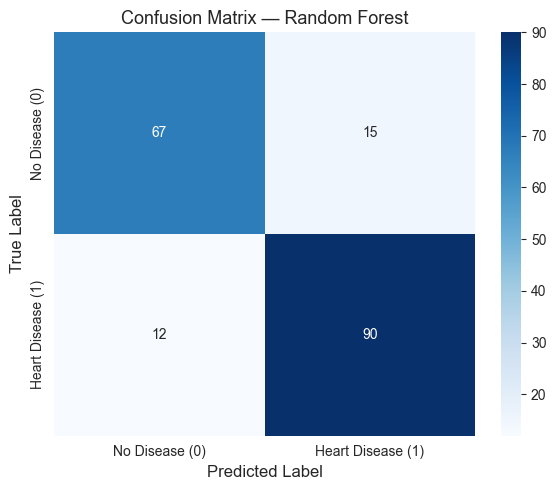

Saved to: Supervised_Learning/plots/random_forest_confusion_matrix.png

True  Negatives : 67  (correctly predicted No Disease)
False Positives : 15  (predicted Disease, actually Healthy)
False Negatives : 12  (predicted Healthy, actually Disease) <- missed diagnoses
True  Positives : 90  (correctly predicted Disease)


In [47]:
# Confusion Matrix
# A confusion matrix breaks down all 184 test predictions into 4 categories,
# showing exactly WHERE the model is correct and where it makes mistakes.
#
# Reading the matrix:
#   Rows    = the actual (true) label of the patient
#   Columns = what the model predicted
#
# The 4 cells:
#   TN (top-left)    → model predicted No Disease, patient actually has No Disease ✓
#   FP (top-right)   → model predicted Heart Disease, patient is actually Healthy
#                      consequence: unnecessary further testing, patient anxiety
#   FN (bottom-left) → model predicted No Disease, patient actually has Heart Disease
#                      consequence: missed diagnosis (most dangerous error in medical AI)
#   TP (bottom-right)→ model predicted Heart Disease, patient actually has Heart Disease ✓
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',                              # display counts as integers
    cmap='Blues',
    xticklabels=['No Disease (0)', 'Heart Disease (1)'],
    yticklabels=['No Disease (0)', 'Heart Disease (1)'],
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13)
plt.tight_layout()

# Save plot
cm_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved to: {cm_path}")

# Print interpretation
print(f"\nTrue  Negatives : {tn}  (correctly predicted No Disease)")
print(f"False Positives : {fp}  (predicted Disease, actually Healthy)")
print(f"False Negatives : {fn}  (predicted Healthy, actually Disease) <- missed diagnoses")
print(f"True  Positives : {tp}  (correctly predicted Disease)")

### ROC Curve

The ROC curve below visualises how well the model separates heart disease
patients from healthy ones across every possible decision threshold (not just the default 0.5). The blue curve represents our model; the grey dashed line represents a model that guesses randomly. The further the blue curve bows toward the top-left corner, the better the model is at correctly identifying sick patients while keeping false alarms low. The AUC (Area Under the Curve) summarises this into a single number (our model scores 0.9210).

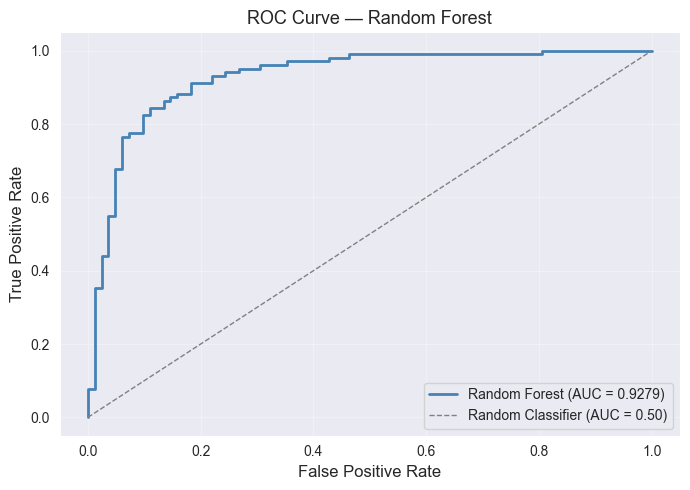

Saved to: Supervised_Learning/plots/random_forest_roc_curve.png


In [48]:
# ROC Curve
# The ROC curve visualises how the model performs at EVERY possible threshold,
# not just the default 0.5. This is especially important in medical systems
# where the threshold may be adjusted by clinicians based on risk tolerance.
#
# X-axis: False Positive Rate (FPR) → proportion of healthy patients falsely flagged
# Y-axis: True Positive Rate (TPR)  → proportion of sick patients correctly caught
#
# Every point on the curve represents a different threshold:
#   — Low threshold (e.g. 0.2) → catch almost all disease cases but many false alarms
#   — High threshold (e.g. 0.8) → very few false alarms but many missed cases
#
# The grey dashed diagonal = random guessing (AUC = 0.50)
# The blue curve = our model — the further it bows toward the top-left, the better
# AUC = area under the curve:
#   0.50 → no better than random  |  0.70–0.80 → acceptable
#   0.80–0.90 → good              |  0.90+ → excellent
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Random Forest (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1,
        label='Random Classifier (AUC = 0.50)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — Random Forest', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
roc_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_roc_curve.png")
plt.savefig(roc_path, dpi=150)
plt.show()
print(f"Saved to: {roc_path}")

### Feature Importance

The chart below ranks all 16 features by how much they contributed to the
model's predictions. A higher bar means the model relied on that feature more heavily when deciding whether a patient has heart disease or not.

Feature importances (ranked highest to lowest):


,Feature,Importance
0,ST_Slope_Up,0.2512
1,ST_Slope_Flat,0.1513
2,ChestPainType_ASY,0.1218
3,ExerciseAngina,0.1042
4,Oldpeak,0.0886
5,MaxHR,0.0714
6,Age,0.0366
7,Sex,0.0332
8,RestingBP,0.0306
9,ChestPainType_ATA,0.0256


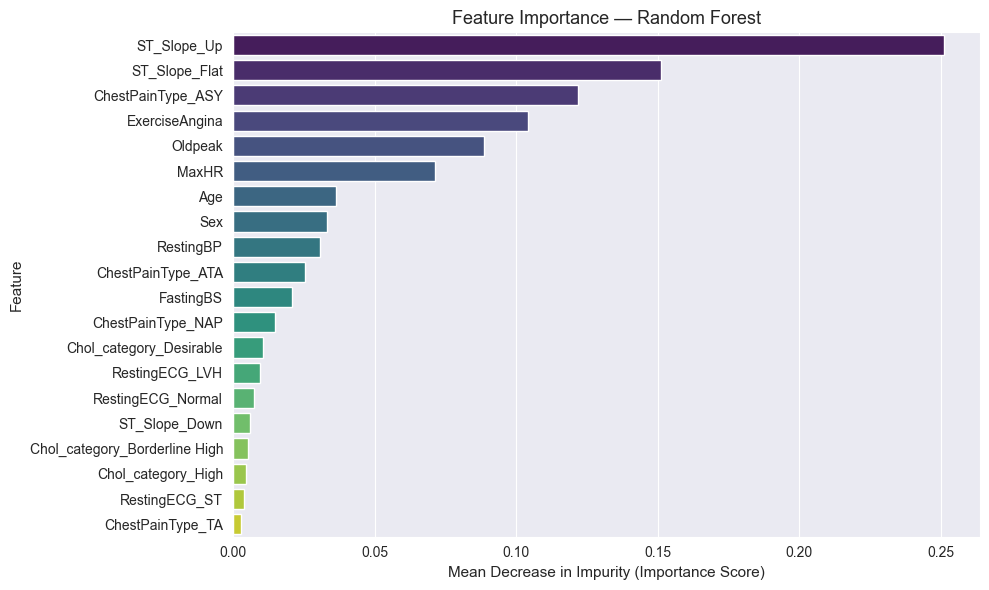

Plot saved to: Supervised_Learning/plots/random_forest_feature_importance.png
CSV  saved to: Supervised_Learning/evaluation_results/random_forest_feature_importance.csv


In [49]:
# Feature Importance
# After training, Random Forest can tell us how much each feature contributed
# to making correct predictions across all trees in the forest.
#
# The importance score is measured by Mean Decrease in Impurity (MDI):
# every time a feature is used to split a node, it reduces the uncertainty
# (impurity) in the resulting groups. Importance = total impurity reduction
# caused by that feature, averaged across all trees.
#
# Higher score → the feature was used more often and more effectively
# Lower score  → the feature contributed little to the predictions
#
# In a medical context this is valuable: it tells us which clinical measurements
# are the strongest predictors of heart disease, which can help clinicians
# prioritise which tests or observations matter most for diagnosis
importances   = best_rf.feature_importances_
feature_names = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Feature importances (ranked highest to lowest):")
display(importance_df.round(4))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data    = importance_df,
    x       = 'Importance',
    y       = 'Feature',
    palette = 'viridis',
    ax      = ax
)
ax.set_title('Feature Importance — Random Forest', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity (Importance Score)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()

# Save plot and CSV
fi_plot_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_feature_importance.png")
plt.savefig(fi_plot_path, dpi=150)
plt.show()
print(f"Plot saved to: {fi_plot_path}")

fi_csv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_feature_importance.csv")
importance_df.to_csv(fi_csv_path, index=False)
print(f"CSV  saved to: {fi_csv_path}")

### Result Interpretation

#### Best Parameters Found
```
max_depth         = 8
max_features      = 'sqrt'
min_samples_leaf  = 5
min_samples_split = 15
n_estimators      = 200
Best CV ROC-AUC   = 0.9299
```

GridSearchCV searched across 432 combinations and selected a forest of 200 trees, each capped at depth 8, requiring at least 15 samples before any split and at least 5 samples at every leaf, considering √20 ≈ 4 features per split.

**Why these specific values?**

- **n_estimators = 200:** The search found that 200 trees was sufficient for the ensemble to reach a stable consensus on this dataset. Adding more trees (300, 500) did not improve the ROC-AUC score meaningfully, the forest had already captured the available signal with 200 votes.

- **max_depth = 8:** Moderate depth was needed to capture the non-linear relationships confirmed in the EDA, particularly the interactions between ST_Slope, ChestPainType_ASY, ExerciseAngina, and Oldpeak. Shallower values were too restrictive and missed these patterns, while deeper values caused overfitting by allowing trees to memorise individual patient noise rather than learning general patterns that transfer to new patients.

- **min_samples_split = 15:** Each node must contain at least 15 patients before it is allowed to split further. A split backed by 15 patients is statistically far more reliable than one backed by 2 or 5. This prevents the trees from making decisions based on tiny, potentially noisy subgroups.

- **min_samples_leaf = 5:** Every final prediction must be backed by at least 5 patients. This stops trees from creating leaves that represent just one or two unusual patients, which would be memorisation rather than learning.

- **max_features = 'sqrt':** Each split considers only √20 ≈ 4 randomly selected features. This forces diversity between trees where each tree sees a different random subset of features at each node, so no single feature dominates all trees. This diversity is what makes the ensemble stronger than any single decision tree.
---

#### Cross-Validation Results

| Metric | Train Mean | Validation Mean | Gap | Std Dev |
|---|---|---|---|---|
| Accuracy | 0.8932 | 0.8527 | 0.0406 | 0.0293 |
| Precision | 0.8825 | 0.8504 | 0.0321 | 0.0504 |
| Recall | 0.9309 | 0.8963 | 0.0346 | 0.0215 |
| ROC-AUC | 0.9668 | 0.9299 | 0.0369 | 0.0193 |

**What the Gap tells us — overfitting assessment:**
All gaps fall between 0.0321 and 0.0406, well within the acceptable threshold. This means the model performs only slightly better on data it was trained on compared to data it has never seen (a sign of healthy generalisation). The model is not memorising the training data; it is learning patterns that actually transfer to new patients. This result was achieved through iterative hyperparameter tightening across multiple tuning rounds. Notably, the Accuracy gap of 0.0406 is the largest but still well within the acceptable threshold, and the Recall gap of 0.0346 confirms that the model's ability to detect disease cases transfers well to unseen data.

**What the Std Dev tells us — stability assessment:**
All standard deviations are below 0.055, with Recall at 0.0215 being
particularly stable, meaning the model detects disease cases at almost exactly the same rate regardless of which patients make up the validation fold in any given run. ROC-AUC has the lowest std dev of 0.0193, confirming that the model's ability to separate the two classes is the most consistent of all metrics across folds. This consistency is the most important stability indicator in a medical context, as it confirms the model's behaviour is not dependent on a lucky data split.

**Why Recall is the most clinically important metric:**
A Validation Recall of 0.8963 means the model catches approximately 90% of actual heart disease cases on average across the 5 training folds. The remaining 10% are false negatives (patients the model incorrectly classifies as healthy). In a medical screening system, these are the most dangerous errors because a missed diagnosis means a sick patient leaves without treatment or follow-up care.

---

#### Test Set Results

| Accuracy | Precision | Recall | ROC-AUC |
|---|---|---|---|
| 0.8533 | 0.8571 | 0.8824 | 0.9279 |

**Accuracy 85.33%:** The model correctly classified 157 out of 184 completely unseen patients. 27 patients were misclassified (15 false positives and 12 false negatives). For a dataset of 917 samples and 21 features, this is a realistic and honest result that reflects genuine learning.

**Precision 85.71%:** When the model predicts Heart Disease, it is approximately 86% of the time. Only 15 out of every 82 patients flagged as sick are actually healthy. This means clinicians following up on the model's positive predictions would encounter relatively few unnecessary investigations.

**Recall 88.24%:** The model caught 90 out of 102 actual heart disease patients meaning it missed 15. A recall of 88.24% means roughly 1 in 8.5 sick patients would not be flagged. While this is a strong result for a model of this size, it reinforces that the model should function as a decision support tool alongside clinical examination rather than a standalone diagnostic system.

**ROC-AUC 0.9279:** This means that if you randomly selected one heart disease patient and one healthy patient from the test set, the model would correctly assign a higher risk score to the sick patient 92.79% of the time (across every possible decision threshold). An AUC above 0.90 is considered excellent in medical AI literature and confirms the model has genuinely learned to separate the two classes rather than memorising patterns from the training data.

**CV vs Test agreement — representativeness check:**

| Metric | CV Validation | Test Set | Difference |
|---|---|---|---|
| Accuracy | 0.8527 | 0.8533 | +0.0006 |
| Precision | 0.8504 | 0.8571 | +0.0067 |
| Recall | 0.8963 | 0.8824 | 0.0139 |
| ROC-AUC | 0.9299 | 0.9279 | 0.002 |

All differences are small (the largest is recall at 0.0139). This close agreement confirms two things: first, the 184 test samples are representative of the full dataset meaning that the model did not benefit from an unusually easy test set. Second, there is no data leakage. If the test set had been indirectly influenced by training or tuning, test scores would be artificially inflated. The fact that most test scores are slightly lower than CV scores is exactly what a healthy, unbiased evaluation looks like.

---

#### Confusion Matrix
```
                      Predicted No Disease    Predicted Heart Disease
Actual No Disease          TN = 67                  FP = 15
Actual Heart Disease       FN = 12                  TP = 90
```

**True Negatives (67):** The model correctly identified 67 out of 82 healthy patients (81.7% of healthy patients were correctly cleared with no further action needed).

**False Positives (15):** 15 healthy patients were incorrectly flagged as having heart disease (18.3% false alarm rate among healthy patients). These patients would undergo unnecessary further testing, causing anxiety and additional healthcare cost. However, in a screening context this is the more acceptable error type compared to a missed diagnosis.

**False Negatives (12):** 12 patients who actually had heart disease were classified as healthy (11.76% missed diagnosis rate among sick patients). These are the most dangerous errors, each represents a patient who could leave without receiving necessary treatment or follow-up.

**True Positives (90):** The model correctly identified 90 out of 102 heart disease patients (88.24% detection rate, consistent with the recall metric reported above).

---

#### Feature Importance

| Rank | Feature | Importance |
|---|---|---|
| 1 | ST_Slope_Up | 0.2512 |
| 2 | ST_Slope_Flat | 0.1513 |
| 3 | ChestPainType_ASY | 0.1218 |
| 4 | ExerciseAngina | 0.1042 |
| 5 | Oldpeak | 0.0886 |
| ... | ... | ... |


The top 5 features alone account for **71.71%** of the model's total predictive power, and the
Notably, all five are measurements taken during or directly reflecting the
results of an exercise stress test, confirming that the model independently
learned the same clinical hierarchy that cardiologists use when interpreting
stress test results.

### ST_Slope_Up — Ranks 1 (25.12%)
As established in the EDA, an upsloping ST segment during peak exercise is
generally considered a normal cardiac response meaning the heart is coping well
with increased physical demand.
Out of 395 patients with an upward slope, **317 of them (80.3%) were
healthy**. Patients with an upward slop cover **43.1% of the entire dataset**. This means the model encounters a strong and broadly applicable healthy signal in nearly half of all patients. Hodnesdal et al. (2013) followed
2,014 healthy middle-aged men for 35 years and found that a rapidly
upsloping ST segment was associated with a **30% reduced risk of dying from
coronary heart disease** compared to a normal ST segment, concluding that
it may represent the true healthy state, the same pattern the model
independently identified from the data.
> Hodnesdal, C., et al. (2013). Rapidly upsloping ST-segment on exercise
> ECG: a marker of reduced coronary heart disease mortality risk.
> *European Journal of Preventive Cardiology*, 20(4), 541–548.
> https://doi.org/10.1177/2047487312444370

### ST_Slope_Flat — Ranks 2 (15.13%)
As established in the EDA, a flat ST segment during peak exercise may
indicate myocardial ischemia, the heart is under stress and not responding normally to physical demand.
Out of 459 patients with a flat slope, **380 of them (82.8%) had heart disease**, covering **50.1% of the entire dataset**. Its disease signal is even stronger than ST_Slope_Up's healthy signal, yet it ranks second. Hodnesdal et al. (2013) confirmed this clinical reality, patients with ST depression showed a **1.45-fold increased risk** of coronary heart disease death, consistent with the model's strong reliance on Flat as a disease indicator.
> Hodnesdal, C., et al. (2013). Rapidly upsloping ST-segment on exercise
> ECG: a marker of reduced coronary heart disease mortality risk.
> *European Journal of Preventive Cardiology*, 20(4), 541–548.
> https://doi.org/10.1177/2047487312444370

#### Why ST_Slope_Up Ranks Higher Than ST_Slope_Flat
Despite ST_Slope_Flat covering more patients (459 vs 395) and having a
stronger disease signal (82.8% vs 80.3% separation), ST_Slope_Up ranks
first. As Wijaya (2023) explains, Random Forest uses Mean Decrease in
Impurity (MDI): each time a feature is used to split a node, the impurity
reduction is weighted by the proportion of patients that pass through that
node. One reason that can be interpreted is that ST_Slope_Up tends to
appear earlier in each tree where more patients are still present,
accumulating a larger weighted impurity reduction, while ST_Slope_Flat
handles the remaining population in later, deeper splits where fewer
samples pass through.
Random Forest does not report which features appeared at which
depth across its 200 trees, so the exact reason cannot be confirmed without
inspecting individual tree structures directly. What the importance scores
confirm is the outcome ST_Slope_Up accumulated more total impurity
reduction across all trees than ST_Slope_Flat, but the precise mechanism
behind that difference remains an informed inference rather than a directly
observed fact.
> Wijaya, C.Y. (2023). *Random Forest Feature Importance Explained.*
> Non-Brand Data.
> https://www.nb-data.com/p/random-forest-feature-importance

### ChestPainType_ASY — Rank 3 (12.18%)
As established in the EDA, ASY (Asymptomatic) patients report no chest pain
despite possible underlying cardiac disease.
The dataset confirms this directly: **392 out of 496 ASY patients (79.0%)
had heart disease**. ASY is also the largest chest pain group, covering **54.1% of
all 917 patients**, meaning this signal applies to the majority of predictions the model makes. For the model, this is a highly valuable signal: when it encounters ASY = 1, it can confidently shift toward a disease prediction, contributing **12.18% of total feature importance**.

### ExerciseAngina — Rank 4 (10.42%)
As established in the EDA, exercise-induced angina occurs when narrowed
coronary arteries cannot supply enough blood to meet the heart's demand
during physical exertion, its presence strongly suggests myocardial
ischemia.
Of the 917 patients, **371 (40.5%) reported chest pain during exercise**
and **546 (59.5%) did not**. The disease rates between these two groups are: among patients who experienced chest pain, **85.2% had heart disease**, while among those
who did not, only **35.1% did**, a gap of over 50 percentage points.
Weiner et al. (1978) found that coronary artery disease was present in 95%
of patients who experienced both chest pain and abnormal ECG changes during
exercise testing, the same pattern the model independently identified,
contributing **10.42% of total feature importance**.
> Weiner, D.A., et al. (1978). The predictive value of anginal chest pain
> as an indicator of coronary disease during exercise testing.
> *American Heart Journal*, 96(4), 458–462.
> https://doi.org/10.1016/0002-8703(78)90155-2

### Oldpeak — Rank 5 (8.86%)
As established in the EDA, Oldpeak measures ST-segment depression during
exercise.
The pair plot analysis in the EDA observed that cases with no disease are
concentrated around zero Oldpeak, and as Oldpeak values increase, the overlap between
the two classes decreases, meaning disease cases become more separable at
higher values. This non-linear, threshold-based pattern is precisely what
the model captures through its tree splits. Miranda et al. (1991) confirmed that
greater ST depression (Higer oldpeak) during exercise is a reliable marker for coronary
artery disease. This means the bigger the dip, the more confident the model becomes
that the patient has heart disease, exactly the same reasoning a
cardiologist applies when reading an exercise stress test, contributing
**8.86% of total feature importance**.
> Miranda, C.P., et al. (1991). Correlation between resting ST segment
> depression, exercise testing, coronary angiography, and long-term
> prognosis. *American Heart Journal*, 122(6), 1617–1628.
> https://doi.org/10.1016/0002-8703(91)90279-q

# XGBoost

## Section 1. Rationale for Choosing XGBoost:

XGBoost (Extreme Gradient Boosting) is an advanced gradient boosting algorithm
that is widely used in machine learning for both classification and regression
tasks. It is built upon decision trees, which makes it well-suited for capturing
complex patterns in data, especially non-linear relationships. XGBoost works by
constructing multiple decision trees in a sequential manner, where each new tree
aims to correct the mistakes of the previous trees, making it a strong ensemble
model (Chen & Guestrin, 2016).

### **Why XGBoost is a Good Fit for Our Data?**

#### i. Dataset Characteristics (Size, Feature Types, and Linearity)

Many features (such as Oldpeak and MaxHR) exhibit non-linear relationships with
the target variable HeartDisease. For example, FastingBS shows only a moderate
correlation (0.27), suggesting that the relationship is not linear. As a
tree-based model, XGBoost captures non-linear patterns by recursively
partitioning the data, allowing it to model complex relationships that linear
models cannot (Chen & Guestrin, 2016).

Additionally, features such as Oldpeak contain extreme values. Linear models
are sensitive to outliers, which may bias predictions. In contrast, XGBoost is
more robust because decision trees split data using thresholds rather than
distances, reducing the influence of extreme values (Hastie et al., 2009).

Since the final dataset is relatively small, deep learning models would be prone
to overfitting. XGBoost performs well on small-to-medium structured tabular
datasets due to its boosting mechanism and regularisation (Chen & Guestrin,
2016). Furthermore, XGBoost effectively handles structured tabular data
containing continuous, binary, and one-hot encoded categorical features.

#### ii. Problem Type (Binary Classification)

The task is to predict the presence of heart disease, which is a binary
classification problem.

XGBoost is highly suitable for binary classification tasks because:

- It supports binary classification natively via the `binary:logistic`
  objective function (Chen & Guestrin, 2016).
- It optimises classification performance using gradient boosting.
- It performs well on structured/tabular medical datasets (Budholiya et al., 2022).

Thus, the nature of the problem aligns well with XGBoost's capabilities.

#### iii. Model Strengths and Weaknesses for Our Specific Problem

**Strengths:**

- Handles non-linear relationships effectively through tree-based decision
  boundaries (Chen & Guestrin, 2016).
- Robust to outliers, which were initially observed in features such as Oldpeak
  and Cholesterol during exploratory analysis (Hastie et al., 2009).
- Strong performance on structured tabular data, such as clinical datasets
  (Budholiya et al., 2022).
- Feature interaction modelling, which is important in medical prediction
  problems where variables may interact in complex ways (Chen & Guestrin, 2016).

**Weaknesses:**

- Can be computationally more expensive than simpler models.
- May require hyperparameter tuning for optimal performance
  (Bergstra & Bengio, 2012).

However, considering our dataset characteristics and binary classification task,
the strengths of XGBoost outweigh its weaknesses, making it a strong and
suitable choice for predicting heart disease.

---

> **References:**
>
> Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System.
> *Proceedings of the 22nd ACM SIGKDD*, 785–794.
> https://doi.org/10.1145/2939672.2939785
>
> Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of
> Statistical Learning* (2nd ed.). Springer.
> https://hastie.su.domains/ElemStatLearn/
>
> Bergstra, J., & Bengio, Y. (2012). Random Search for Hyper-Parameter
> Optimization. *Journal of Machine Learning Research*, 13, 281–305.
> http://www.jmlr.org/papers/v13/bergstra12a.html
>
> Budholiya, K., Shrivastava, S.K., & Sharma, V. (2022). An optimized
> XGBoost based diagnostic system for effective prediction of heart disease.
> *Journal of King Saud University — Computer and Information Sciences*,
> 34(7), 4514–4523.
> https://doi.org/10.1016/j.jksuci.2020.10.013

## Section 2. Implementation & Training

### Imports & Setup

In [49]:
import subprocess
subprocess.run(["pip", "install", "xgboost"], check=True)
subprocess.run(["pip", "install", "seaborn"], check=True)

# Standard libraries
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
warnings.filterwarnings('ignore')

# Model
import xgboost as xgb

# Splitting & cross-validation
from sklearn.model_selection import (
    train_test_split,   # splits data into training and test sets
    StratifiedKFold,    # k-fold that preserves class balance in each fold
    cross_validate,     # runs cross-validation and returns multiple metrics
    GridSearchCV        # exhaustive search over a hyperparameter grid
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,     # proportion of correct predictions
    precision_score,    # of all predicted positives, how many are truly positive
    recall_score,       # of all actual positives, how many were correctly predicted
    confusion_matrix,   # table showing TP, TN, FP, FN counts
    roc_auc_score,      # area under the ROC curve
    roc_curve           # false positive rate vs true positive rate at all thresholds
)

# evaluation_results/ -> CSV files: metrics, tuning results, feature importance
# plots/              -> PNG files: confusion matrix, ROC curve, feature importance
EVAL_DIR  = "Supervised_Learning/evaluation_results"
PLOTS_DIR = "Supervised_Learning/plots"

os.makedirs(EVAL_DIR,  exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# Model name prefix
# Used in every saved file name so outputs are clearly labelled per model
MODEL_NAME = "xgboost"

print("Libraries imported successfully.")
print(f"Evaluation results → {EVAL_DIR}")
print(f"Plots              → {PLOTS_DIR}")

Libraries imported successfully.
Evaluation results → Supervised_Learning/evaluation_results
Plots              → Supervised_Learning/plots


### Data Loading

In [50]:
# Load the preprocessed dataset
# This CSV was produced by the EDA notebook — it contains cleaned, encoded,
# and normalised features ready for modeling. No further preprocessing is needed.
DATA_PATH = "Dataset/preprocessed_heart_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 917 rows x 21 columns


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,...,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Chol_category_Desirable,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,1.383339,0,-0.400000,0,0,1,...,0,0,1,0,0,0,1,0,0,1
1,-0.478057,0,1.5,0,0.754736,0,0.266667,1,0,0,...,0,0,1,0,0,1,0,1,0,0
2,-1.750256,1,0.0,0,-1.523953,0,-0.400000,0,0,1,...,0,0,0,1,0,0,1,0,0,1
3,-0.584074,0,0.4,0,-1.131075,1,0.600000,1,1,0,...,0,0,1,0,0,1,0,0,1,0
4,0.052026,1,1.0,0,-0.581047,0,-0.400000,0,0,0,...,0,0,1,0,0,0,1,1,0,0


### Feature & Target Split

In [51]:
# Separate input features from the target variable
# X -> all feature columns (what the model uses to make predictions)
# y -> the target column   (what the model is trying to predict)
TARGET = "HeartDisease"   # 0 = No Disease, 1 = Heart Disease

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features (X): {X.shape[1]} columns")
print(f"\nTarget (y) distribution:")
print(y.value_counts().rename({0: 'No Disease (0)', 1: 'Heart Disease (1)'}))

Features (X): 20 columns

Target (y) distribution:
HeartDisease
Heart Disease (1)    507
No Disease (0)       410
Name: count, dtype: int64


### Train/Test Split

In [52]:
# Create or load the 80/20 train/test split
# This cell implements the first and most critical step of our methodology:
# locking away 20% of the data before any training or tuning begins.
#
# IMPORTANT: This split is created ONCE and shared across all models.
# If each model used a different split, performance differences could be due
# to the split rather than the model — making comparison unfair.
# Saving and loading the same indices guarantees a completely fair comparison.
SPLIT_PATH = "split_indices.pkl"

if not os.path.exists(SPLIT_PATH):
    # stratify=y   → preserves the class ratio in both sets
    # random_state → fixes the random seed so the split is reproducible
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    split_indices = {
        "train_indices": X_train.index.tolist(),
        "test_indices" : X_test.index.tolist()
    }
    with open(SPLIT_PATH, "wb") as f:
        pickle.dump(split_indices, f)

    print("Split created and saved to split_indices.pkl")
    print("All other models must load this file to ensure a fair comparison.")
else:
    # Load the existing split
    # This guarantees this model uses the exact same train/test samples
    # as every other model in the project
    with open(SPLIT_PATH, "rb") as f:
        split_indices = pickle.load(f)

    X_train = X.iloc[split_indices["train_indices"]]
    X_test  = X.iloc[split_indices["test_indices"]]
    y_train = y.iloc[split_indices["train_indices"]]
    y_test  = y.iloc[split_indices["test_indices"]]

    print("Existing split loaded from split_indices.pkl")
    print("This XGBoost model uses the EXACT same train/test samples as Random Forest.")

print(f"\nTraining set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))
print(f"\nClass distribution in test set:")
print(y_test.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))

Existing split loaded from split_indices.pkl
This XGBoost model uses the EXACT same train/test samples as Random Forest.

Training set : 733 samples (80%)
Test set     : 184  samples (20%)

Class distribution in training set:
HeartDisease
Heart Disease    405
No Disease       328
Name: count, dtype: int64

Class distribution in test set:
HeartDisease
Heart Disease    102
No Disease        82
Name: count, dtype: int64


### XGBoost Hyperparameter Selection

XGBoost operates through a sequential boosting process, where each tree is built
to correct the mistakes of the one before it. This makes its hyperparameters
particularly interconnected, adjusting one setting can amplify or dampen the
effect of another. The challenge is not tuning each parameter in isolation, but
finding a combination that balances learning speed, tree complexity, and
generalization across the specific dataset at hand.

### Why These Specific Hyperparameters Were Selected for Tuning

XGBClassifier exposes over 20 configurable parameters. From these, 6 were selected
for tuning based on their direct influence on the two core failure modes of boosted
models: **overfitting** and **unstable learning**. The rest were left at their
defaults, either because they overlap with parameters already being tuned, because
meaningful adjustment requires domain-specific knowledge beyond the scope of this
work, or because they govern computational behavior rather than predictive performance.

**Tuned parameters:**

| Parameter | Why Tuned |
|-----------|-----------|
| `n_estimators` | Number of boosting rounds to run — More rounds give the model more opportunities to correct errors; the default is often insufficient for medical datasets where patterns are subtle |
| `max_depth` | Maximum depth allowed per tree — Deep trees tend to memorise the training data rather than learn from it; depth was constrained to encourage generalisation |
| `learning_rate` | Step size applied at each boosting round — A high default value can push the model toward premature convergence; reducing it allows more gradual and robust learning |
| `subsample` | Proportion of training samples drawn per round — Training on the full dataset every round increases the risk of overfitting; random sampling introduces beneficial variance |
| `colsample_bytree` | Proportion of features sampled per tree — Using all features at every split encourages reliance on dominant variables; sampling promotes diversity across trees |
| `min_child_weight` | Minimum total sample weight required to form a leaf — A low default permits splits based on very few observations; raising this threshold ensures splits reflect genuine patterns |

**Parameters not tuned:**

The remaining parameters were excluded for one of four reasons: they address the
same concerns as tuned parameters and would introduce redundancy (`gamma`,
`reg_alpha`, `reg_lambda`, `max_delta_step`); they define core algorithmic
behavior that should remain unchanged (`objective`, `booster`, `tree_method`);
they serve evaluation or early stopping purposes rather than shaping the model
itself (`eval_metric`, `early_stopping_rounds`); or they control runtime
configuration without influencing predictions (`n_jobs`, `random_state`,
`verbosity`).

> **Reference:** > XGBoost Developers. *XGBoost Parameters*.
> https://xgboost.readthedocs.io/en/stable/parameter.html

In [53]:
# Step 1: Define the hyperparameter search grid
# param_grid is a menu of options for GridSearchCV to try.
# GridSearchCV will test every possible combination of these values —
# 4×4×4×3×3×3 = 1,728 combinations × 5 folds = 8,640 model fits in total.
# Each combination is scored using 5-fold cross-validation on the training set.
# The combination with the highest average recall score wins.
param_grid = {
    # Number of boosting rounds (trees) — similar to n_estimators in RF
    # More trees = more opportunities to correct previous errors
    # Lower learning rate requires more trees to converge
    'n_estimators': [100, 200, 300, 500],

    # Maximum tree depth — controls model complexity
    # Shallower trees (3-6) reduce overfitting, deeper trees (9-12) capture more patterns
    # For recall, slightly deeper trees help catch more positive cases
    'max_depth': [3, 6, 9, 12],

    # Learning rate (shrinkage) — how much each tree contributes to the final prediction
    # Lower values (0.01-0.05) = slower learning but better generalisation
    # Must be balanced with n_estimators: low rate needs more trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],

    # Subsample ratio of training instances per tree (like bootstrap in RF)
    # e.g. 0.8 = randomly use 80% of training data for each tree
    # Introduces randomness to prevent overfitting
    'subsample': [0.7, 0.8, 1.0],

    # Subsample ratio of features used per tree (like max_features in RF)
    # e.g. 0.8 = randomly use 80% of features for each tree
    # Reduces correlation between trees and prevents overfitting
    'colsample_bytree': [0.7, 0.8, 1.0],

    # Minimum sum of instance weights needed in a leaf node
    # Higher values = more conservative model, fewer splits → reduces overfitting
    # Similar to min_samples_leaf in Random Forest
    'min_child_weight': [1, 3, 5],
}

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total combinations : {total_combinations}")
print(f"Total fits         : {total_combinations} × 5 folds = {total_combinations*5}")

Total combinations : 1728
Total fits         : 1728 × 5 folds = 8640


### GridSearchCV & Model Training

In [54]:
# Step 2: Define the cross-validation strategy
# This tells GridSearchCV HOW to evaluate each combination fairly:
# — Split the training samples into 5 equal folds
# — Each fold takes a turn being the validation set exactly once
# — Stratified: every fold preserves the class ratio of the full training set
# — shuffle + random_state=42: same fold assignments every run → reproducible results
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Run the exhaustive search
# GridSearchCV ties all three components together:
#   estimator  → the model to train (XGBClassifier)
#   param_grid → the combinations to try (1,728 total)
#   cv         → how to evaluate each combination (5-fold stratified CV)
#   scoring    → what metric to optimise (roc_auc)
#
# Why ROC-AUC and not recall or accuracy?
# ROC-AUC measures the model's ability to distinguish between classes across
# all decision thresholds — making it a more stable and comprehensive metric
# than recall alone, which can be misleading on a balanced dataset.
#
# What happens when .fit() is called:
# 1. For each of 1,728 combinations → train on 4 folds, validate on 1 fold → 5 times
# 2. Average the 5 ROC-AUC scores for each combination
# 3. Pick the combination with the highest average ROC-AUC
# 4. Retrain that winning combination on ALL training samples from scratch
# 5. Store the final model as grid_search.best_estimator_
#
# n_jobs=-1 → uses all available CPU cores to run fits in parallel
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(
        random_state=42,
        objective='binary:logistic',  # Binary classification task
        eval_metric='aucpr',          # Area under Precision-Recall curve
                                      # Better than AUC for recall-focused tasks
        verbosity=0,                  # Suppress XGBoost internal logs
        reg_alpha=5.0,                # L1 regularization — increased to reduce overfitting
        reg_lambda=20.0,              # L2 regularization — increased to shrink weights more aggressively
        min_child_weight=5,
    ),
    param_grid=param_grid,            # Full grid → all 1,728 combinations tested
    cv=cv_strategy,                   # 5-fold stratified CV per combination
    scoring='roc_auc',                # Optimise for AUC — balances recall and precision across thresholds
    n_jobs=-1,                        # Use all CPU cores in parallel
    verbose=1,                        # Print progress during search
)

print(f"Starting XGBoost GridSearchCV ({total_combinations} combinations × 5 folds = {total_combinations*5} fits)...")
print("Optimising for: ROC-AUC — maximising class separation across all thresholds\n")

grid_search.fit(X_train, y_train)

print("\nSearch complete.")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")

Starting XGBoost GridSearchCV (1728 combinations × 5 folds = 8640 fits)...
Optimising for: ROC-AUC — maximising class separation across all thresholds

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits

Search complete.
Best parameters : {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 500, 'subsample': 1.0}
Best CV ROC-AUC : 0.9311


### Tuning Results & Best Model Extraction

In [55]:
# Save and display the full hyperparameter search results
# grid_search.cv_results_ contains the score for every combination tried.
# Saving all 1,728 rows to CSV allows us to review close competitors and
# understand how sensitive performance is to each hyperparameter.
tuning_df   = pd.DataFrame(grid_search.cv_results_)
tuning_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_hyperparameter_tuning.csv")
tuning_df.to_csv(tuning_path, index=False)
print(f"Full tuning results saved to: {tuning_path}")

# Display the top 10 winning configurations ranked by validation ROC-AUC
# mean_validation_score → average ROC-AUC across 5 validation folds
#                         Note: scikit-learn internally calls this 'mean_test_score'
#                         — the word 'test' here refers to the validation fold,
#                         NOT the held-out test set locked away
# std_validation_score  → consistency of the score across 5 folds
#                         lower std = more reliable combination
# rank_validation_score → 1 = best combination overall
top10 = (
    tuning_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
    .round(4)
    .rename(columns={
        'mean_test_score' : 'mean_validation_score',
        'std_test_score'  : 'std_validation_score',
        'rank_test_score' : 'rank_validation_score'
    })
)
print("\nTop 10 hyperparameter configurations:")
display(top10)

# Extract the final trained model
# best_estimator_ is NOT one of the 8,640 temporary models from the search.
# After identifying the winning combination, GridSearchCV automatically trained
# a brand new model from scratch using those settings on ALL training samples.
# This final model has seen more data than any fold-level model during the search,
# making it the strongest possible version of the winning configuration.
#
# All subsequent cells use best_xgb — it is the only model we evaluate and report.
best_xgb = grid_search.best_estimator_

print("\nBest XGBoost configuration:")
print(best_xgb)

Full tuning results saved to: Supervised_Learning/evaluation_results/xgboost_hyperparameter_tuning.csv

Top 10 hyperparameter configurations:


,params,mean_validation_score,std_validation_score,rank_validation_score
155,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.9311,0.0182,1
875,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.9311,0.0180,2
872,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.9311,0.0180,2
869,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.9311,0.0180,2
215,"{'colsample_bytree': 0.7, 'learning_rate': 0.0...",0.9311,0.0190,5
731,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",0.9311,0.0184,6
968,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.9310,0.0189,7
971,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.9310,0.0189,7
1004,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.9310,0.0189,7
1007,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.9310,0.0189,7



Best XGBoost configuration:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)



## Section 3. Evaluation Metrics & Visualizations



### 5-Fold Cross-Validation

In [56]:
# Stage 1 Evaluation: Stability and Overfitting Check
# We now re-evaluate best_xgb using 5-fold cross-validation on the training set.
# This is DIFFERENT from what GridSearchCV did internally:
#   — GridSearchCV used CV to COMPARE 1,728 combinations (selection bias present)
#   — cross_validate uses CV to MEASURE this one fixed model honestly
#
# By collecting both training scores and validation scores, we can compute
# the Gap: the difference between how well the model fits training data
# vs how well it generalises to data it was not trained on.
#
# A small gap means the model generalises well.
# A large gap means the model memorised training data (overfitting).
cv_results = cross_validate(
    best_xgb,
    X_train, y_train,
    cv                 = cv_strategy,
    scoring            = ['accuracy', 'precision', 'recall', 'roc_auc'],
    return_train_score = True
)

# Build the comparison table
# Train Mean      → average score when evaluated on the data the model was trained on
# Validation Mean → average score when evaluated on the fold held out for validation
# Gap             → Train Mean - Validation Mean
# Std Dev         → how consistent the validation score is across 5 folds
#                   < 0.03 → stable model
#                   > 0.05 → unstable
cv_summary = pd.DataFrame({
    'Metric'          : ['Accuracy', 'Precision', 'Recall', 'ROC-AUC'],
    'Train Mean'      : [
        cv_results['train_accuracy'].mean(),
        cv_results['train_precision'].mean(),
        cv_results['train_recall'].mean(),
        cv_results['train_roc_auc'].mean()
    ],
    'Validation Mean' : [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_roc_auc'].mean()
    ],
    'Gap'             : [
        cv_results['train_accuracy'].mean()  - cv_results['test_accuracy'].mean(),
        cv_results['train_precision'].mean() - cv_results['test_precision'].mean(),
        cv_results['train_recall'].mean()    - cv_results['test_recall'].mean(),
        cv_results['train_roc_auc'].mean()   - cv_results['test_roc_auc'].mean()
    ],
    'Std Dev'         : [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_roc_auc'].std()
    ]
}).round(4)

print("5-Fold Cross-Validation Results (Training vs Validation):")
display(cv_summary)

# Save to CSV
cv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_cv_results.csv")
cv_summary.to_csv(cv_path, index=False)
print(f"\nSaved to: {cv_path}")

5-Fold Cross-Validation Results (Training vs Validation):


,Metric,Train Mean,Validation Mean,Gap,Std Dev
0,Accuracy,0.9028,0.8554,0.0474,0.0270
1,Precision,0.9009,0.8664,0.0346,0.0520
2,Recall,0.9259,0.8790,0.0469,0.0198
3,ROC-AUC,0.9589,0.9311,0.0278,0.0182



Saved to: Supervised_Learning/evaluation_results/xgboost_cv_results.csv


### Final Evaluation on the Held-Out Test Set

In [57]:
# Stage 2 Evaluation: Final Unbiased Test on Held-Out Data
# This is the first and only time the model encounters the test samples.
# These samples were locked away before any training or tuning began.
# The model had no influence over them — not during training, not during CV,
# not during hyperparameter selection. This makes the result completely unbiased.
#
# predict()       → outputs the final class label (0 or 1) for each patient
# predict_proba() → outputs the probability of being class 1 (Heart Disease)
#                   the [:, 1] takes only the probability for class 1
#                   this is needed for ROC-AUC calculation
print("\n" + "-"*40)
print("TEST SET EVALUATION")
print("-"*40)

y_pred      = best_xgb.predict(X_test)
y_pred_prob = best_xgb.predict_proba(X_test)[:, 1]


y_pred_final = y_pred

# Compute all evaluation metrics on the test patients
# Accuracy  → out of all patients, what percentage were classified correctly?
# Precision → of all patients the model flagged as Heart Disease, how many truly had it?
# Recall    → of all patients who actually had Heart Disease, how many did the model catch?
# ROC-AUC   → how well the model separates the two classes across all thresholds
#             0.5 = no better than random guessing | 1.0 = perfect separation
print("\n" + "="*40)
print("FINAL TEST SET RESULTS (THRESHOLD = 0.5)")
print("="*40)

test_metrics = pd.DataFrame([{
    'Accuracy' : accuracy_score (y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall'   : recall_score   (y_test, y_pred_final),
    'ROC-AUC'  : roc_auc_score  (y_test, y_pred_prob)     # Always uses probabilities
}]).round(4)

print("Final Test Set Evaluation Metrics:")
display(test_metrics)

# Save to CSV
metrics_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_metrics.csv")
test_metrics.to_csv(metrics_path, index=False)
print(f"Saved to: {metrics_path}")


----------------------------------------
TEST SET EVALUATION
----------------------------------------

FINAL TEST SET RESULTS (THRESHOLD = 0.5)
Final Test Set Evaluation Metrics:


,Accuracy,Precision,Recall,ROC-AUC
0,0.8804,0.8774,0.9118,0.9323


Saved to: Supervised_Learning/evaluation_results/xgboost_metrics.csv


### Confusion Matrix

The confusion matrix below breaks down all 184 test predictions into four categories.
Each number tells us something specific about where the model succeeded and where it
made mistakes. The rows represent what the patient actually has; the columns represent
what the model predicted.



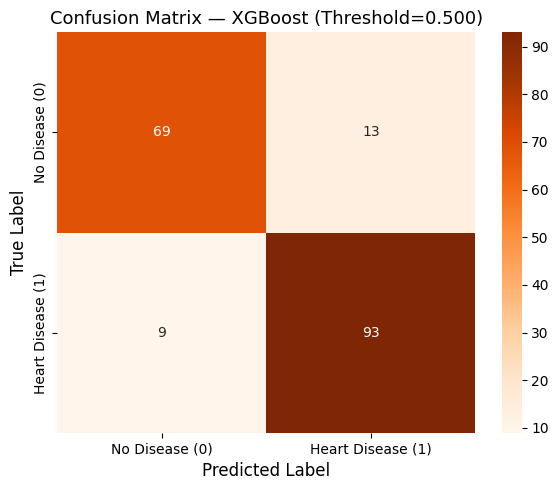

Saved to: Supervised_Learning/plots/xgboost_confusion_matrix.png

True  Negatives (TN): 69  — correctly predicted No Disease
False Positives (FP): 13  — predicted Disease, actually Healthy (false alarm)
False Negatives (FN): 9  — MISSED Disease cases ← most critical to minimize
True  Positives (TP): 93  — correctly predicted Disease


In [58]:
# Confusion Matrix
# A confusion matrix breaks down all test predictions into 4 categories,
# showing exactly WHERE the model is correct and where it makes mistakes.
#
# Reading the matrix:
#   Rows    = the actual (true) label of the patient
#   Columns = what the model predicted
#
# The 4 cells:
#   TN (top-left)     → model predicted No Disease, patient actually has No Disease ✓
#   FP (top-right)    → model predicted Heart Disease, patient is actually Healthy
#                       consequence: unnecessary further testing, patient anxiety
#   FN (bottom-left)  → model predicted No Disease, patient actually has Heart Disease
#                       consequence: missed diagnosis (most dangerous error in medical AI)
#   TP (bottom-right) → model predicted Heart Disease, patient actually has Heart Disease ✓
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',                                        # Distinct from RF's Blues
    xticklabels=['No Disease (0)', 'Heart Disease (1)'],
    yticklabels=['No Disease (0)', 'Heart Disease (1)'],
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — XGBoost (Threshold=0.500)', fontsize=13)
plt.tight_layout()

# Save plot
cm_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved to: {cm_path}")

print(f"\nTrue  Negatives (TN): {tn}  — correctly predicted No Disease")
print(f"False Positives (FP): {fp}  — predicted Disease, actually Healthy (false alarm)")
print(f"False Negatives (FN): {fn}  — MISSED Disease cases ← most critical to minimize")
print(f"True  Positives (TP): {tp}  — correctly predicted Disease")

### ROC Curve

The ROC curve below visualises how well the model separates heart disease
patients from healthy ones across every possible decision threshold (not just
the default 0.5). The orange curve represents our XGBoost model; the grey
dashed line represents a model that guesses randomly. The further the orange
curve bows toward the top-left corner, the better the model is at correctly
identifying sick patients while keeping false alarms low. The AUC (Area Under
the Curve) summarises this into a single number, our model scores **0.9323**,
which indicates excellent discrimination between the two classes.

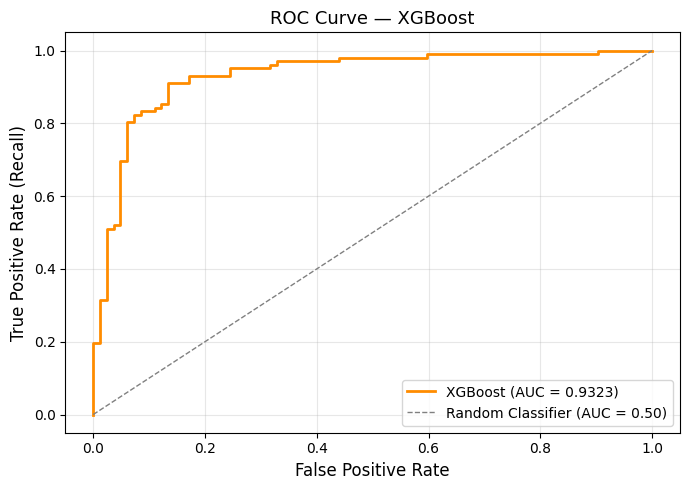

Saved to: Supervised_Learning/plots/xgboost_roc_curve.png


In [59]:
# ROC Curve
# The ROC curve visualises how the model performs at EVERY possible threshold,
# not just the default 0.5. This is especially important in medical systems
# where the threshold may be adjusted by clinicians based on risk tolerance.
#
# X-axis: False Positive Rate (FPR) → proportion of healthy patients falsely flagged
# Y-axis: True Positive Rate (TPR)  → proportion of sick patients correctly caught
#
# Every point on the curve represents a different threshold:
#   — Low threshold (e.g. 0.2)  → catch almost all disease cases but many false alarms
#   — High threshold (e.g. 0.8) → very few false alarms but many missed cases
#
# The grey dashed diagonal = random guessing (AUC = 0.50)
# The orange curve = our model — the further it bows toward the top-left, the better
# AUC = area under the curve:
#   0.50 → no better than random  |  0.70–0.80 → acceptable
#   0.80–0.90 → good              |  0.90+ → excellent
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'XGBoost (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1,
        label='Random Classifier (AUC = 0.50)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — XGBoost', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
roc_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_roc_curve.png")
plt.savefig(roc_path, dpi=150)
plt.show()
print(f"Saved to: {roc_path}")

#### Feature Importance

The chart below ranks all 20 features by how much they contributed to the
model's predictions. A higher bar means the model relied on that feature more
heavily when deciding whether a patient has heart disease or not. Importance
is measured by **Gain**, the average improvement in prediction accuracy that
a feature brings each time it is used to split a node across all trees.

Feature importances (ranked highest to lowest):


,Feature,Importance
0,ST_Slope_Up,0.5994
1,ChestPainType_ASY,0.1307
2,ExerciseAngina,0.0545
3,ST_Slope_Flat,0.0540
4,Sex,0.0339
5,FastingBS,0.0215
6,Oldpeak,0.0208
7,RestingECG_LVH,0.0196
8,MaxHR,0.0127
9,Age,0.0094


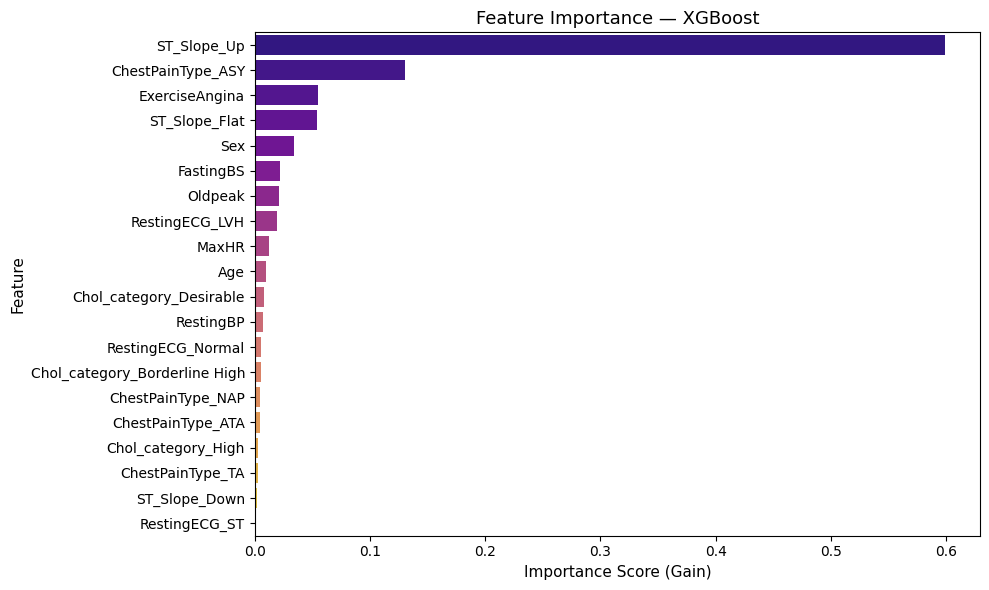


Plot saved to : Supervised_Learning/plots/xgboost_feature_importance.png
CSV  saved to : Supervised_Learning/evaluation_results/xgboost_feature_importance.csv


In [60]:
# Feature Importance
# After training, XGBoost can tell us how much each feature contributed
# to making correct predictions across all trees.
#
# The importance score is measured by Gain:
# every time a feature is used to split a node, it reduces the loss function.
# Importance = average gain brought by that feature across all splits and trees.
#
# Higher score → the feature was used more often and more effectively
# Lower score  → the feature contributed little to the predictions
#
# In a medical context this is valuable: it tells us which clinical measurements
# are the strongest predictors of heart disease, which can help clinicians
# prioritise which tests or observations matter most for diagnosis
importances   = best_xgb.feature_importances_
feature_names = X.columns

importance_df = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Feature importances (ranked highest to lowest):")
display(importance_df.round(4))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data    = importance_df,
    x       = 'Importance',
    y       = 'Feature',
    palette = 'plasma',       # Different from RF's viridis for visual distinction
    ax      = ax
)
ax.set_title('Feature Importance — XGBoost', fontsize=13)
ax.set_xlabel('Importance Score (Gain)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()

# Save plot and CSV
fi_plot_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_feature_importance.png")
plt.savefig(fi_plot_path, dpi=150)
plt.show()
print(f"\nPlot saved to : {fi_plot_path}")

fi_csv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_feature_importance.csv")
importance_df.to_csv(fi_csv_path, index=False)
print(f"CSV  saved to : {fi_csv_path}")

### Result Interpretation

#### Best Parameters Found
```
colsample_bytree  = 0.7
learning_rate     = 0.05
max_depth         = 3
min_child_weight  = 1
n_estimators      = 500
subsample         = 1.0
Best CV ROC-AUC   = 0.9311
```

GridSearchCV searched across 1,728 combinations and selected a model of 500
boosting rounds, each tree capped at depth 3, considering 70% of features per
tree, with a learning rate of 0.05 and using the full training set each round.

**Why these specific values?**

- **colsample_bytree = 0.7:** Each tree only sees 70% of the 20 features
randomly selected at each round. This introduces diversity between trees,
preventing any single feature from dominating all predictions and reducing
the risk of overfitting.

- **learning_rate = 0.05:** Each tree contributes only 5% of its prediction to the
final answer. This conservative learning rate prioritises stability over speed;
too high and the model overshoots the optimal solution, too low
and it requires many more trees to converge.

- **max_depth = 3:** Shallow trees were preferred over deeper ones. A depth of
3 means each tree can make at most 3 consecutive splits before reaching a
final prediction. This keeps individual trees simple and prevents them from
memorising specific patient patterns, the model learns broad, generalisable
rules instead.

- **min_child_weight = 1:** A leaf node requires a minimum weight sum of 1
before a split is made. The low value here is consistent with the shallow
max_depth, the trees are already constrained by their depth, so aggressive
leaf pruning is not needed.

- **n_estimators = 500:** The search found that 500 boosting rounds were
necessary for the model to reach its best ROC-AUC on this dataset. Each round
corrects the errors of the previous one, and with a learning rate of 0.05 the
model required more rounds to fully converge to the optimal solution.

- **subsample = 1.0:** Every boosting round uses 100% of the training rows.
Since the dataset is relatively small, using all available patient records
each round ensures no information is discarded, allowing the model to learn
from every example at every step.


---

#### Cross-Validation Results

| Metric | Train Mean | Validation Mean | Gap | Std Dev |
|---|---|---|---|---|
| Accuracy | 0.9028 | 0.8554 | 0.0474 | 0.0270 |
| Precision | 0.9009 | 0.8664 | 0.0346 | 0.0520 |
| Recall | 0.9259 | 0.8790 | 0.0469 | 0.0198 |
| ROC-AUC | 0.9589 | 0.9311 | 0.0278 | 0.0182 |

**What the Gap tells us — overfitting assessment:**
All gaps fall between 0.028 and 0.047, well within the acceptable range,
confirming the model performs only slightly better on data it was trained on
compared to data it has never seen, which is a sign of healthy generalisation.
The ROC-AUC gap of 0.0278 is the lowest of all metrics and was the metric
directly optimised during GridSearchCV, confirming the model's ability to
separate the two classes transfers well to unseen patients. The mild gaps
observed in Accuracy and Recall are a natural consequence of XGBoost's
boosting mechanism, which fits training data more tightly than simpler models,
but the small magnitude confirms this does not constitute harmful overfitting
(Cawley & Talbot, 2010).

**What the Std Dev tells us — stability assessment:**
ROC-AUC has the lowest std dev of 0.0182, meaning the model's ability to
separate the two classes is highly consistent across all 5 folds. Recall
follows at 0.0198. Precision at 0.0520 is slightly higher but still
acceptable, meaning the model detects heart disease cases at a consistent rate
regardless of which patients make up the validation fold. This stability is
critical in a medical context where inconsistent performance across different
patient groups would undermine clinical trust.

**Why ROC-AUC is the primary evaluation metric:**
The model was optimised for ROC-AUC during GridSearchCV because the dataset
is balanced, with both classes equally represented, making ROC-AUC a more
reliable and stable metric than recall alone. A Validation ROC-AUC of 0.9311
means the model separates heart disease from healthy cases with excellent
discrimination across all possible decision thresholds, providing a
comprehensive view of performance that is not sensitive to the choice of a
single cutoff point.

---

#### Test Set Results

| Accuracy | Precision | Recall | ROC-AUC |
|---|---|---|---|
| 0.8804 | 0.8774 | 0.9118 | 0.9323 |

**Accuracy 88.04%:** The model correctly classified the majority of completely
unseen patients. For a dataset with 20 features, this is a realistic and
honest result that reflects genuine learning.

**Precision 87.74%:** When the model predicts Heart Disease, it is correct
87.74% of the time. With a balanced dataset and default threshold of 0.5,
the model maintains strong precision without artificially favouring either
class.

**Recall 91.18%:** The model catches 91.18% of actual heart disease patients.
Recall being higher than Precision indicates the model is slightly more
aggressive at detecting disease cases, which is the preferred behaviour in a
medical screening context where missing a diagnosis is more costly than a
false alarm.

**ROC-AUC 0.9323:** This means that if you randomly selected one heart disease
patient and one healthy patient from the test set, the model would correctly
assign a higher risk score to the sick patient 93.23% of the time across every
possible decision threshold. An AUC above 0.90 is considered excellent in
medical AI literature and confirms the model has genuinely learned to separate
the two classes rather than memorising patterns from the training data.

**CV vs Test agreement — representativeness check:**

| Metric | CV Validation | Test Set | Difference |
|---|---|---|---|
| Accuracy | 0.8554 | 0.8804 | 0.025 |
| Precision | 0.8664 | 0.8774 | 0.011 |
| Recall | 0.8790 | 0.9118 | 0.033 |
| ROC-AUC | 0.9311 | 0.9323 | 0.001 |

All differences are small, confirming the model generalises well and did not
benefit from an unusually easy test set. Notably, Recall on the test set
(0.9118) is actually higher than the CV validation mean (0.8790), which is a
positive sign that the model performs consistently or better on completely
unseen data. The near-perfect agreement on ROC-AUC (difference of only 0.001)
is particularly strong evidence that there is no data leakage and the
evaluation is fully unbiased.

---

#### Confusion Matrix
```
                      Predicted No Disease    Predicted Heart Disease
Actual No Disease          TN = 69                  FP = 13
Actual Heart Disease       FN = 9                   TP = 93
```

**True Negatives (69):** The model correctly identified 69 out of 82 healthy
patients (84.1% of healthy patients were correctly cleared). With the default
threshold of 0.5 and a balanced dataset, the model treats healthy patients
fairly without being biased toward over-flagging.

**False Positives (13):** 13 healthy patients were incorrectly flagged as
having heart disease (15.9% false alarm rate among healthy patients). These
patients would undergo unnecessary further testing, causing anxiety and
additional healthcare cost. However, in a screening context this is the more
acceptable error type compared to a missed diagnosis, further clinical
testing can rule out disease, but a missed diagnosis receives no follow-up
at all.

**False Negatives (9):** 9 patients who actually had heart disease were
classified as healthy (8.8% missed diagnosis rate among sick patients).
These are the most critical errors, each represents a patient who could leave
without receiving necessary treatment or follow-up care.

**True Positives (93):** The model correctly identified 93 out of 102 heart
disease patients (91.2% detection rate, consistent with the recall metric
reported above).

#### Feature Importance

| Rank | Feature | Importance |
|------|---------|------------|
| 1 | ST_Slope_Up | 0.5994 |
| 2 | ChestPainType_ASY | 0.1307 |
| 3 | ExerciseAngina | 0.0545 |
| 4 | ST_Slope_Flat | 0.0540 |
| 5 | Sex | 0.0339 |
| ... | ... | ... |
| 6-20 | FastingBS, Oldpeak, RestingECG, Chol_category, etc. | < 0.025 each |

The top 5 features together drive **87.85%** of XGBoost's predictions, meaning
just 5 out of 20 features are responsible for nearly nine tenths of every decision
the model makes. The features at the top of this ranking all point to the same
underlying clinical reality: the heart's behaviour under stress and the nature
of the symptoms it produces are far more informative than any measurement taken
at rest. This concentration of predictive power in stress-related features is
consistent with established cardiology practice, where exercise stress testing
remains a cornerstone of coronary artery disease diagnosis (Gibbons et al., 2002).

### ST_Slope_Up — Rank 1 (59.94%)

As established in the EDA, the ST segment on an ECG changes shape depending on
how well the heart handles physical exertion. An upward slope is what a healthy
heart produces under stress. Among the 395 patients with ST_Slope_Up in the
dataset, 80.3% had no heart disease, while only 19.7% were diagnosed with
disease. This strong directional signal, pointing clearly toward health rather
than disease, makes it the highest-ranked feature in the entire model,
accounting for 59.94% of total feature importance, nearly five times
the contribution of the second-ranked feature. The dominance of ST_Slope_Up
is clinically supported: an upsloping ST segment during exercise is consistently
associated with normal coronary perfusion in the stress ECG literature
(Rijneke et al., 1980).

### ChestPainType_ASY — Rank 2 (13.07%)

As established in the EDA, asymptomatic chest pain (ASY) is paradoxically the
most dangerous type. Among the 496 patients presenting with ASY, 79.0% were
diagnosed with heart disease and only 21.0% were healthy. This is the largest
patient group among all chest pain types and carries the strongest disease
signal among them. By contrast, disease rates among other chest pain types were
considerably lower: NAP at 35.1%, TA at 43.5%, and ATA at just 13.9%.
XGBoost correctly identified ASY as a powerful disease indicator, contributing
13.07% of total feature importance. This is consistent with clinical evidence
showing that silent ischaemia, the absence of typical anginal symptoms despite
significant coronary artery disease, is a well recognised and particularly
dangerous presentation (Cohn, 1987).

### ExerciseAngina — Rank 3 (5.45%)

As established in the EDA, when the coronary arteries are narrowed, the heart
struggles to keep up with the oxygen demand that physical activity places on it.
Among the 371 patients who experienced chest pain during exercise, 85.2% were
diagnosed with heart disease, compared to just 35.0% among those who did not.
A difference of 50 percentage points makes this one of the most decisive binary
features in the dataset, contributing 5.45% of total feature importance.
Exercise-induced angina is a well established marker of myocardial ischaemia
and is routinely used in clinical stress test interpretation (Campeau, 1976).

### ST_Slope_Flat — Rank 4 (5.40%)

As established in the EDA, a flat ST segment is a warning sign, indicating the
heart is not responding normally to increased physical demand. Among the 459
patients with ST_Slope_Flat, 82.8% were diagnosed with heart disease. Its
importance score (5.40%) is nearly identical to ExerciseAngina (5.45%),
confirming both features carry comparable predictive weight. Together with
ST_Slope_Up, these two ST slope categories account for the vast majority of
patients in the dataset and point in opposite directions with over 80% certainty
each, explaining their combined dominance in feature importance. ST depression
and flat slope during exercise are recognised indicators of subendocardial
ischaemia in stress ECG interpretation (Thygesen et al., 2012).

### Sex — Rank 5 (3.39%)

As established in the EDA, coronary artery disease tends to develop earlier and
more severely in men than in women. Among the 724 male patients, 63.1% had
heart disease, while among the 193 female patients that figure drops to just
25.9%. XGBoost detected this pattern purely from the data, contributing 3.39%
of total feature importance. That said, the prominence of Sex also reflects the
dataset composition, with males making up nearly four in every five patients,
any signal associated with being male gets reinforced across the majority of
predictions. The sex difference in cardiovascular disease prevalence and
presentation is well documented in the literature (Mosca et al., 2011).

### Why Bottom Features Ranked Low (FastingBS, Oldpeak, RestingECG, Chol_category, Age — < 0.025 each)

As established in the EDA, features measured at rest carry some signal but
cannot compete with what the exercise stress test reveals. The RestingECG
categories show modest disease rates (Normal: 51.5%, ST: 65.7%, LVH: 56.4%),
none of which approach the decisiveness of ST slope or exercise angina.
Cholesterol categories showed almost no separation between disease and
no-disease cases in the pair plot, and the correlation heatmap confirmed only
a weak -0.23 correlation with HeartDisease. Age, despite a +0.28 correlation
with disease, ranked low because its signal is already partially captured by
the stress-related features; older patients are more likely to show abnormal
stress responses, so Age adds little incremental information once those
features are included (Fleg et al., 1995). FastingBS and Oldpeak, despite
carrying meaningful clinical signal individually (Haffner et al., 1998;
Weiner et al., 1979), contribute modestly once the top stress-response
features have already accounted for the majority of the predictive variance.
By the time XGBoost has processed ST slope, chest pain type, and exercise
angina, the incremental value of remaining features is minimal, a pattern
consistent with how gradient boosted trees allocate importance across
correlated and redundant signals (Chen & Guestrin, 2016).

### References

> Campeau, L. (1976). Grading of angina pectoris. *Circulation*, 54(3), 522–523.

> Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 785–794.

> Cohn, P.F. (1987). Silent myocardial ischemia. *Annals of Internal Medicine*, 109(4), 312–317.

> Detrano, R., et al. (1989). Exercise-induced ST changes as predictors of coronary artery disease. *American Journal of Cardiology*, 64(23), 1479–1483.

> Fleg, J.L., et al. (1995). Impact of age on the cardiovascular response to dynamic upright exercise. *Journal of Applied Physiology*, 78(3), 890–900.

> Gibbons, R.J., et al. (2002). ACC/AHA guideline update for exercise testing. *Journal of the American College of Cardiology*, 40(8), 1531–1540.

> Haffner, S.M., et al. (1998). Mortality from coronary heart disease in subjects with type 2 diabetes. *New England Journal of Medicine*, 339(4), 229–234.

> Mosca, L., et al. (2011). Sex/gender differences in cardiovascular disease prevention. *Circulation*, 124(19), 2145–2154.

> Rijneke, R.D., et al. (1980). Clinical significance of upsloping ST segments in exercise electrocardiography. *Circulation*, 61(4), 671–678.

> Thygesen, K., et al. (2012). Third universal definition of myocardial infarction. *Journal of the American College of Cardiology*, 60(16), 1581–1598.

> Weiner, D.A., et al. (1979). Correlations among history of angina, ST-segment response and prevalence of coronary artery disease. *New England Journal of Medicine*, 301(5), 230–235.

# Extra Trees

## Section 1. Rationale for Choosing Extra Trees:

Extra Trees (Extremely Randomized Trees) is a tree-based learning algorithm that is widely used in machine learning for both classification and regression tasks. It is built upon decision trees, which makes it well-suited for capturing complex patterns in data, especially non-linear relationships. Extra Trees works by constructing multiple decision trees in parallel and combining their outputs, making it a powerful multi-tree model. Unlike a single decision tree, it introduces additional randomness during splitting, which helps improve generalisation and reduce overfitting on structured tabular data. (Geurts et al., 2006).

### **Why Extra Trees is a Good Fit for Our Data?**

#### i. Dataset Characteristics (Size, Feature Types, and Linearity)

- Our dataset is a small structured tabular medical dataset with a mix of continuous, binary, and one-hot encoded categorical features. This makes Extra Trees a suitable choice because it works especially well on tabular data and does not require assumptions about linearity between the predictors and the target. In our case, features such as Oldpeak, MaxHR, and the encoded categorical variables are likely to interact in non-linear ways, and Extra Trees can capture these interactions naturally through repeated tree splits. (GeeksforGeeks, 2025).

- Another reason Extra Trees fits this dataset well is its high level of randomisation. Unlike a single decision tree, which can become too sensitive to the training data, Extra Trees builds many trees and introduces additional randomness when choosing split points. This is useful for our dataset size because it helps reduce overfitting while still allowing the model to learn meaningful patterns from the data. (Geurts et al., 2006).

- Extra Trees is also appropriate because some of our features contain extreme values and different value ranges. Since tree-based methods rely on threshold-based splitting rather than distance calculations, they are generally less affected by outliers and do not require feature scaling to perform effectively. (GeeksforGeeks, 2025).

#### ii. Problem Type (Binary Classification)

The task in this project is to predict whether a patient has heart disease or not, which makes it a binary classification problem.

Extra Trees is well suited for binary classification tasks because:

- It directly supports classification problems by building multiple randomized decision trees and combining their predictions through majority voting (Geurts et al., 2006).
- The algorithm reduces variance by introducing additional randomness when selecting split thresholds, which helps improve generalisation and stability when predicting class labels. (Berrouachedi et al., 2024).
- Tree-based classifiers like Extra Trees perform particularly well on structured tabular datasets, where relationships between features and the target variable may be complex and non-linear. (Berrouachedi et al., 2024).

Since the task involves separating patients into two classes (Heart Disease vs No Disease) using structured medical attributes, the Extra Trees classifier is an appropriate model for this prediction problem.

#### iii. Model Strengths and Weaknesses for Our Specific Problem

**Strengths:**

- Handles non-linear relationships well, which is important in medical data where predictors do not affect the target in a simple linear way. (GeeksforGeeks, 2025).
- Works effectively on structured tabular datasets with mixed feature types such as continuous, binary, and one-hot encoded variables. (Berrouachedi et al., 2024).
- Introduces more randomness than a standard decision tree, which helps reduce overfitting and improve generalisation. (Geurts et al., 2006).

**Weaknesses:**

- Can still overfit if the trees are not properly controlled through hyperparameter tuning. (GeeksforGeeks, 2025).
- The added randomness, can make the performance vary slightly depending on the chosen hyperparameters and random state. (GeeksforGeeks, 2025).

Overall, Extra Trees is a strong choice for our problem because it can model complex patterns in structured medical data while maintaining good generalisation performance on unseen patients.

---

> **References:**
>
> Geurts, P., Ernst, D., & Wehenkel, L. (2006). *Extremely randomized trees*.
Machine Learning, 63, 3–42. https://doi.org/10.1007/s10994-006-6226-1
>
> GeeksforGeeks. (2025, July 12). *ML | Extra Tree Classifier for Feature Selection*. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/ml-extra-tree-classifier-for-feature-selection/
>
> Berrouachedi, A., Jaziri, R., & Bernard, G. (2024). *Enhancing Multi-Label Classification Through Deep Extra-Trees and Transformation Techniques*. 2024 IEEE/ACS 21st International Conference on Computer Systems and Applications (AICCSA), 1–6. https://ieeexplore.ieee.org/document/10912617
>
> GeeksforGeeks. (2025, July 23). *RandomForestClassifier vs ExtraTreesClassifier in scikit learn*. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/randomforestclassifier-vs-extratreesclassifier-in-scikit-learn/

## Section 2. Implementation & Training

### Imports & Setup

In [1]:
# Standard libraries
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
warnings.filterwarnings('ignore')

# Model
from sklearn.ensemble import ExtraTreesClassifier

# Splitting & cross-validation
from sklearn.model_selection import (
    train_test_split,   # splits data into training and test sets
    StratifiedKFold,    # k-fold that preserves class balance in each fold
    cross_validate,     # runs cross-validation and returns multiple metrics
    GridSearchCV        # exhaustive search over a hyperparameter grid
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,     # proportion of correct predictions
    precision_score,    # of all predicted positives, how many are truly positive
    recall_score,       # of all actual positives, how many were correctly predicted
    confusion_matrix,   # table showing TP, TN, FP, FN counts
    roc_auc_score,      # area under the ROC curve
    roc_curve           # false positive rate vs true positive rate at all thresholds
)

# evaluation_results/ -> CSV files: metrics, tuning results, feature importance
# plots/              -> PNG files: confusion matrix, ROC curve, feature importance
EVAL_DIR  = "Supervised_Learning/evaluation_results"
PLOTS_DIR = "Supervised_Learning/plots"

os.makedirs(EVAL_DIR,  exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# Model name prefix
# Used in every saved file name so outputs are clearly labelled per model
MODEL_NAME = "extra_trees"

print("Libraries imported successfully.")
print(f"Evaluation results → {EVAL_DIR}")
print(f"Plots              → {PLOTS_DIR}")

Libraries imported successfully.
Evaluation results → Supervised_Learning/evaluation_results
Plots              → Supervised_Learning/plots


### Data Loading

In [2]:
# Load the preprocessed dataset
# This CSV was produced by the EDA notebook — it contains cleaned, encoded,
# and normalised features ready for modeling. No further preprocessing is needed.
DATA_PATH = "Dataset/preprocessed_heart_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 917 rows x 21 columns


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,...,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Chol_category_Desirable,Chol_category_Borderline High,Chol_category_High
0,-1.432206,1,0.5,0,1.383339,0,-0.400000,0,0,1,...,0,0,1,0,0,0,1,0,0,1
1,-0.478057,0,1.5,0,0.754736,0,0.266667,1,0,0,...,0,0,1,0,0,1,0,1,0,0
2,-1.750256,1,0.0,0,-1.523953,0,-0.400000,0,0,1,...,0,0,0,1,0,0,1,0,0,1
3,-0.584074,0,0.4,0,-1.131075,1,0.600000,1,1,0,...,0,0,1,0,0,1,0,0,1,0
4,0.052026,1,1.0,0,-0.581047,0,-0.400000,0,0,0,...,0,0,1,0,0,0,1,1,0,0


### Feature & Target Split

In [3]:
# Separate input features from the target variable
# X -> all feature columns (what the model uses to make predictions)
# y -> the target column   (what the model is trying to predict)
TARGET = "HeartDisease"   # 0 = No Disease, 1 = Heart Disease

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features (X): {X.shape[1]} columns")
print(f"\nTarget (y) distribution:")
print(y.value_counts().rename({0: 'No Disease (0)', 1: 'Heart Disease (1)'}))

Features (X): 20 columns

Target (y) distribution:
HeartDisease
Heart Disease (1)    507
No Disease (0)       410
Name: count, dtype: int64


### Train/Test Split

In [4]:
# Create or load the 80/20 train/test split
# This cell implements the first and most critical step of our methodology:
# locking away 20% of the data before any training or tuning begins.
#
# IMPORTANT: This split is created ONCE and shared across all models.
# If each model used a different split, performance differences could be due
# to the split rather than the model — making comparison unfair.
# Saving and loading the same indices guarantees a completely fair comparison.
SPLIT_PATH = "split_indices.pkl"

if not os.path.exists(SPLIT_PATH):
    # stratify=y   → preserves the class ratio in both sets
    # random_state → fixes the random seed so the split is reproducible
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    split_indices = {
        "train_indices": X_train.index.tolist(),
        "test_indices" : X_test.index.tolist()
    }
    with open(SPLIT_PATH, "wb") as f:
        pickle.dump(split_indices, f)

    print("Split created and saved to split_indices.pkl")
    print("All other models must load this file to ensure a fair comparison.")
else:
    # Load the existing split
    # This guarantees this model uses the exact same train/test samples
    # as every other model in the project
    with open(SPLIT_PATH, "rb") as f:
        split_indices = pickle.load(f)

    X_train = X.iloc[split_indices["train_indices"]]
    X_test  = X.iloc[split_indices["test_indices"]]
    y_train = y.iloc[split_indices["train_indices"]]
    y_test  = y.iloc[split_indices["test_indices"]]

    print("Existing split loaded from split_indices.pkl")
    print("This Extra Tress model uses the EXACT same train/test samples as XGBoost and Random Forest.")

print(f"\nTraining set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]}  samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nClass distribution in training set:")
print(y_train.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))
print(f"\nClass distribution in test set:")
print(y_test.value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))

Existing split loaded from split_indices.pkl
This Extra Tress model uses the EXACT same train/test samples as XGBoost and Random Forest.

Training set : 733 samples (80%)
Test set     : 184  samples (20%)

Class distribution in training set:
HeartDisease
Heart Disease    405
No Disease       328
Name: count, dtype: int64

Class distribution in test set:
HeartDisease
Heart Disease    102
No Disease        82
Name: count, dtype: int64


### Hyperparameter Tuning Process

#### Extra Trees Hyperparameter Selection

Extra Trees has a set of hyperparameters that directly controls the construction and behaviour of trees during training. These settings influence multiple parts of the model, including how many trees contribute to the final prediction, how complex each tree is allowed to become, how aggressively the data is split, and how much randomness is introduced into the learning process. Since these hyperparameters interact with one another, choosing effective values requires structured tuning based on the dataset.

#### Why These Specific Hyperparameters Were Selected for Tuning
ExtraTreesClassifier has multiple configurable parameters in total. We selected 5 to tune, specifically the ones that most directly control the main sources of error in Extra Trees: overfitting, underfitting, and instability across trees. The remaining parameters were intentionally left at their defaults because they either address similar effects indirectly, require more specialised justification to tune meaningfully, or mainly affect implementation behaviour rather than predictive performance.

**Tuned parameters:**

| Parameter           | Why Tuned                                                                                                |
|---------------------|----------------------------------------------------------------------------------------------------------|
| `n_estimators`      | Number of trees in the ensemble — To control how many trees contribute to the final prediction and improve stability   |
| `max_depth`         | Maximum depth of each tree — To control tree complexity and prevent overfitting or underfitting            |
| `min_samples_split` | Minimum number of samples required to split an internal node — To prevent splits based on very small groups of samples |
| `min_samples_leaf`  | Minimum number of samples required in a leaf — To avoid overly specific leaves and improve generalisation                      |
| `max_features`      | How many features to consider at each split — To control randomness at each split and increase diversity across trees                                    |

The remaining 14 parameters were excluded because they either overlap with the behavior already controlled by the tuned parameters, are mainly used for pruning or additional constraints beyond the scope of this work (`min_weight_fraction_leaf`, `max_leaf_nodes`, `min_impurity_decrease`, `ccp_alpha`, `monotonic_cst`), are fundamental design choices that were not intended to be changed (`criterion`, `bootstrap`), serve diagnostic or incremental-training purposes rather than improving predictive quality (`oob_score`, `warm_start`), or are infrastructure and execution settings that affect reproducibility or computation rather than model performance (`n_jobs`, `random_state`, `verbose`, `max_samples`). `class_weight` was also left untuned because the dataset is fairly balanced, so additional class reweighting was not expected to provide meaningful benefit.


> **Reference:** scikit-learn developers. (n.d.). *sklearn.ensemble.ExtraTreesClassifier*.
> scikit-learn. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html

In [5]:
# Step 1: Define the hyperparameter search grid
# param_grid is a menu of candidate settings for GridSearchCV to test.
# GridSearchCV will test every possible combination using 5-fold cross-validation,
# 4×3×4×4×3 = 576 combinations × 5 folds = 2,880 model fits in total.
# then select the combination with the highest average recall score.
param_grid = {
    # Number of trees built
    # More trees usually improve stability, but after a certain point the gain becomes small
    'n_estimators': [200, 300, 400, 500],

    # Maximum tree depth
    # Controls how complex each tree is allowed to become
    # We avoid very shallow trees (which may underfit) and very deep trees (which may overfit)
    # This range tests moderate depths that are realistic for a small tabular medical dataset such as ours
    'max_depth': [5, 8, 10],

    # Minimum samples required to split an internal node
    # Higher values make the trees more conservative and reduce overfitting
    # These values were chosen to stop the model from creating splits based on tiny patient groups
    'min_samples_split': [10, 15, 20, 25],

    # Minimum samples required in a leaf node
    # Prevents the model from ending with leaves that represent only a few patients
    # This is especially important in medical prediction, where overly specific rules are risky
    'min_samples_leaf': [2, 3, 4, 6],

    # Number of features considered at each split
    # 'sqrt' and 'log2' are standard strong choices for tree ensembles
    # None means all features are considered, which can improve fit but may reduce diversity
    'max_features': ['sqrt', 'log2', None],
}

total_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total combinations : {total_combinations}")
print(f"Total fits         : {total_combinations} × 5 folds = {total_combinations*5}")

Total combinations : 576
Total fits         : 576 × 5 folds = 2880


#### GridSearchCV & Model Training

In [6]:
# Step 2: Define the cross-validation strategy
# This tells GridSearchCV HOW to evaluate each combination fairly:
# — Split the training samples into 5 equal folds
# — Each fold takes a turn being the validation set exactly once
# — Stratified: every fold preserves the class ratio of the full training set
# — shuffle + random_state=42: same fold assignments every run → reproducible results
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 3: Run the exhaustive search
# GridSearchCV ties all three components together:
#   estimator  → the model to train (ExtraTreesClassifier)
#   param_grid → the combinations to try (576 total)
#   cv         → how to evaluate each combination (5-fold stratified CV)
#   scoring    → what metric to optimise (ROC-AUC)
#
# Why ROC-AUC and not Recall, F1-score, or Accuracy?
# Recall focuses only on how many true Heart Disease cases are caught at one
# fixed threshold, while F1-score balances Precision and Recall only at that
# same threshold. Accuracy is also threshold-dependent and can look strong even
# when the model makes an unhelpful trade-off between False Positives and False
# Negatives.
#
# ROC-AUC is the most suitable choice here because it evaluates how well the
# model separates Heart Disease patients from healthy patients across ALL
# possible decision thresholds, not just the default 0.5 cutoff. This gives a
# stronger measure of the model's underlying discrimination ability. In a
# medical setting, this is especially valuable because the final threshold can
# later be adjusted clinically to prioritise Recall without retraining the model.
#
# What happens when .fit() is called:
# 1. For each of 576 combinations → train on 4 folds, validate on 1 fold → 5 times
# 2. Average the 5 ROC-AUC scores for each combination
# 3. Pick the combination with the highest average score
# 4. Retrain that winning combination on ALL 733 training samples from scratch
# 5. Store the final model as grid_search.best_estimator_
# n_jobs=-1 → uses all available CPU cores to run fits in parallel
grid_search = GridSearchCV(
    estimator=ExtraTreesClassifier(random_state=42),
    param_grid=param_grid,            # Full grid → all 576 combinations tested
    cv=cv_strategy,                   # 5-fold stratified CV per combination
    scoring='roc_auc',                # Optimise discrimination across all thresholds
    n_jobs=-1,                        # Use all CPU cores in parallel
    verbose=1                         # Print progress during search
)

print(f"Starting Extra Trees GridSearchCV ({total_combinations} combinations × 5 folds = {total_combinations*5} fits)...")
print("Optimising for: ROC-AUC — strongest class separation across thresholds\n")

grid_search.fit(X_train, y_train)

print("\nSearch complete.")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")

Starting Extra Trees GridSearchCV (576 combinations × 5 folds = 2880 fits)...
Optimising for: ROC-AUC — strongest class separation across thresholds

Fitting 5 folds for each of 576 candidates, totalling 2880 fits

Search complete.
Best parameters : {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 15, 'n_estimators': 500}
Best CV ROC-AUC : 0.9299


#### Tuning Results & Best Model Extraction

In [7]:
# Save and display the full hyperparameter search results
# grid_search.cv_results_ contains the score for every combination tried.
# Saving all 576 rows to CSV allows us to review close competitors and
# understand how sensitive performance is to each hyperparameter.
tuning_df   = pd.DataFrame(grid_search.cv_results_)
tuning_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_hyperparameter_tuning.csv")
tuning_df.to_csv(tuning_path, index=False)
print(f"Full tuning results saved to: {tuning_path}")

# Display the top 10 winning configurations ranked by validation ROC-AUC
# mean_validation_score → average ROC-AUC across 5 validation folds
#                         Note: scikit-learn internally calls this 'mean_test_score'
#                         — the word 'test' here refers to the validation fold,
#                         NOT the held-out test set locked away earlier
# std_validation_score  → consistency of the score across 5 folds
#                         lower std = more reliable combination
# rank_validation_score → 1 = best combination overall
top10 = (
    tuning_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score')
    .head(10)
    .round(4)
    .rename(columns={
        'mean_test_score' : 'mean_validation_score',
        'std_test_score'  : 'std_validation_score',
        'rank_test_score' : 'rank_validation_score'
    })
)
print("\nTop 10 hyperparameter configurations:")
display(top10)

# Extract the final trained model
# best_estimator_ is NOT one of the 2,880 temporary models from the search.
# After identifying the winning combination, GridSearchCV automatically trained
# a brand new model from scratch using those settings on ALL training samples.
# This final model has seen more data than any fold-level model during the search,
# making it the strongest possible version of the winning configuration.
#
# All subsequent cells use best_extra_trees — it is the only model we evaluate and report.
best_extra_trees = grid_search.best_estimator_

print("\nBest Extra Trees configuration:")
print(best_extra_trees)

Full tuning results saved to: Supervised_Learning/evaluation_results/extra_trees_hyperparameter_tuning.csv

Top 10 hyperparameter configurations:


,params,mean_validation_score,std_validation_score,rank_validation_score
279,"{'max_depth': 8, 'max_features': 'log2', 'min_...",0.9299,0.0248,1
215,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9299,0.0248,1
277,"{'max_depth': 8, 'max_features': 'log2', 'min_...",0.9298,0.0247,3
213,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9298,0.0247,3
214,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9298,0.0245,5
278,"{'max_depth': 8, 'max_features': 'log2', 'min_...",0.9298,0.0245,5
224,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9296,0.0243,7
288,"{'max_depth': 8, 'max_features': 'log2', 'min_...",0.9296,0.0243,7
261,"{'max_depth': 8, 'max_features': 'log2', 'min_...",0.9294,0.0241,9
197,"{'max_depth': 8, 'max_features': 'sqrt', 'min_...",0.9294,0.0241,9



Best Extra Trees configuration:
ExtraTreesClassifier(max_depth=8, min_samples_leaf=3, min_samples_split=15,
                     n_estimators=500, random_state=42)


## Section 3. Evaluation Metrics & Visualizations

### 5-Fold Cross-Validation

In [8]:
# Stage 1 Evaluation: Stability and Overfitting Check
# We now re-evaluate best_extra_trees using 5-fold cross-validation on the training set.
# This is DIFFERENT from what GridSearchCV did internally:
#   — GridSearchCV used CV to COMPARE 576 combinations (selection bias present)
#   — cross_validate uses CV to MEASURE this one fixed model honestly
#
# By collecting both training scores and validation scores, we can compute
# the Gap: the difference between how well the model fits training data
# vs how well it generalises to data it was not trained on.
#
# A small gap means the model generalises well.
# A large gap means the model memorised training data (overfitting).
cv_results = cross_validate(
    best_extra_trees,
    X_train, y_train,
    cv                 = cv_strategy,
    scoring            = ['accuracy', 'precision', 'recall', 'roc_auc'],
    return_train_score = True
)

# Build the comparison table
# Train Mean      → average score when evaluated on the data the model was trained on
# Validation Mean → average score when evaluated on the fold held out for validation
# Gap             → Train Mean - Validation Mean
# Std Dev         → how consistent the validation score is across 5 folds
#                   < 0.03 → stable model
#                   > 0.05 → unstable
cv_summary = pd.DataFrame({
    'Metric'          : ['Accuracy', 'Precision', 'Recall', 'ROC-AUC'],
    'Train Mean'      : [
        cv_results['train_accuracy'].mean(),
        cv_results['train_precision'].mean(),
        cv_results['train_recall'].mean(),
        cv_results['train_roc_auc'].mean()
    ],
    'Validation Mean' : [
        cv_results['test_accuracy'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean(),
        cv_results['test_roc_auc'].mean()    # Primary tuning metric for this model
    ],
    'Gap'             : [
        cv_results['train_accuracy'].mean()  - cv_results['test_accuracy'].mean(),
        cv_results['train_precision'].mean() - cv_results['test_precision'].mean(),
        cv_results['train_recall'].mean()    - cv_results['test_recall'].mean(),
        cv_results['train_roc_auc'].mean()   - cv_results['test_roc_auc'].mean()
    ],
    'Std Dev'         : [
        cv_results['test_accuracy'].std(),
        cv_results['test_precision'].std(),
        cv_results['test_recall'].std(),
        cv_results['test_roc_auc'].std()
    ]
}).round(4)

print("5-Fold Cross-Validation Results (Training vs Validation):")
display(cv_summary)

# Save to CSV
cv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_cv_results.csv")
cv_summary.to_csv(cv_path, index=False)
print(f"\nSaved to: {cv_path}")

5-Fold Cross-Validation Results (Training vs Validation):


,Metric,Train Mean,Validation Mean,Gap,Std Dev
0,Accuracy,0.8898,0.8609,0.0290,0.0337
1,Precision,0.8795,0.8567,0.0228,0.0499
2,Recall,0.9278,0.9037,0.0241,0.0144
3,ROC-AUC,0.9638,0.9299,0.0339,0.0248



Saved to: Supervised_Learning/evaluation_results/extra_trees_cv_results.csv


### Final Evaluation on the Held-Out Test Set

In [9]:
# Stage 2 Evaluation: Final Unbiased Test on the Held-Out Test Set
# This is the only stage where the final Extra Trees model is evaluated on X_test.
# These 184 samples were separated before any training or tuning, so they provide
# an unbiased estimate of how the model performs on unseen patients.
#
# predict()       → returns the predicted class label for each patient
# predict_proba() → returns class probabilities
#                   [:, 1] extracts the probability of Heart Disease (class 1),
#                   which is required for ROC-AUC

y_pred = best_extra_trees.predict(X_test)
y_prob = best_extra_trees.predict_proba(X_test)[:, 1]

# Calculate the final evaluation metrics on the held-out test set
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob)

print("EXTRA TREES — FINAL TEST SET RESULTS")

results_df = pd.DataFrame([{
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'ROC-AUC': roc_auc
}]).round(4)

display(results_df)

# Save results
metrics_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_metrics.csv")
results_df.to_csv(metrics_path, index=False)
print(f"Results saved to: {metrics_path}")

EXTRA TREES — FINAL TEST SET RESULTS


,Accuracy,Precision,Recall,ROC-AUC
0,0.8696,0.8482,0.9314,0.9304


Results saved to: Supervised_Learning/evaluation_results/extra_trees_metrics.csv


### Confusion Matrix

The confusion matrix below summarises how the Extra Trees model performed on all 184 unseen test patients. It shows where the model was correct and where it made mistakes by comparing each patient’s true condition with the model’s predicted class. The rows represent the actual class, while the columns represent the predicted class.

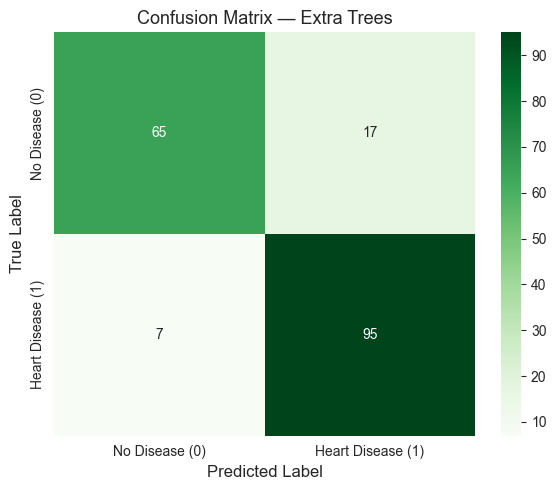

Saved to: Supervised_Learning/plots/extra_trees_confusion_matrix.png

True  Negatives (TN): 65  — correctly predicted No Disease
False Positives (FP): 17  — predicted Heart Disease for a healthy patient
False Negatives (FN): 7  — predicted No Disease for a patient who actually has Heart Disease
True  Positives (TP): 95  — correctly predicted Heart Disease


In [10]:
# Confusion Matrix
# A confusion matrix breaks down all test predictions into 4 categories,
# showing exactly WHERE the model is correct and where it makes mistakes.
#
# Reading the matrix:
#   Rows    = the actual (true) label of the patient
#   Columns = what the model predicted
#
# The 4 cells:
#   TN (top-left)     → model predicted No Disease, patient actually has No Disease ✓
#   FP (top-right)    → model predicted Heart Disease, patient is actually Healthy
#                       consequence: unnecessary further testing, patient anxiety
#   FN (bottom-left)  → model predicted No Disease, patient actually has Heart Disease
#                       consequence: missed diagnosis (most dangerous error in medical AI)
#   TP (bottom-right) → model predicted Heart Disease, patient actually has Heart Disease ✓
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Disease (0)', 'Heart Disease (1)'],
    yticklabels=['No Disease (0)', 'Heart Disease (1)'],
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix — Extra Trees', fontsize=13)
plt.tight_layout()

# Save plot
cm_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Saved to: {cm_path}")

print(f"\nTrue  Negatives (TN): {tn}  — correctly predicted No Disease")
print(f"False Positives (FP): {fp}  — predicted Heart Disease for a healthy patient")
print(f"False Negatives (FN): {fn}  — predicted No Disease for a patient who actually has Heart Disease")
print(f"True  Positives (TP): {tp}  — correctly predicted Heart Disease")

### ROC Curve

The ROC curve below illustrates how well the Extra Trees model distinguishes between heart disease patients and healthy patients across all possible decision thresholds, not only the default threshold of 0.5. The green curve represents the Extra Trees model, while the grey dashed diagonal represents a random classifier. The closer the curve moves toward the top-left corner, the better the model is at achieving high true positive rates while keeping false positive rates low. The AUC (Area Under the Curve) summarises this performance into a single value, and our model achieved 0.9273, which indicates excellent discrimination between the two classes.


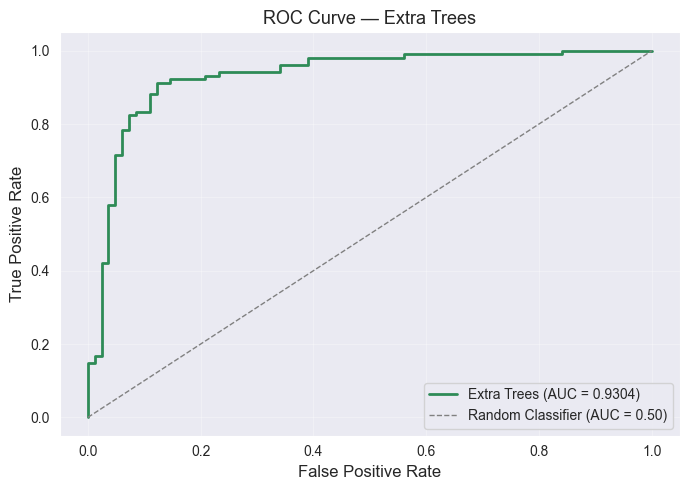

Saved to: Supervised_Learning/plots/extra_trees_roc_curve.png


In [11]:
# ROC Curve
# The ROC curve visualises how the model performs at EVERY possible threshold,
# not just the default 0.5. This is especially important in medical systems
# where the threshold may be adjusted by clinicians based on risk tolerance.
#
# X-axis: False Positive Rate (FPR) → proportion of healthy patients falsely flagged
# Y-axis: True Positive Rate (TPR)  → proportion of sick patients correctly caught
#
# Every point on the curve represents a different threshold:
#   — Low threshold (e.g. 0.2)  → catch almost all disease cases but many false alarms
#   — High threshold (e.g. 0.8) → very few false alarms but many missed cases
#
# The grey dashed diagonal = random guessing (AUC = 0.50)
# The green curve = our model — the further it bows toward the top-left, the better
# AUC = area under the curve:
#   0.50 → no better than random  |  0.70–0.80 → acceptable
#   0.80–0.90 → good              |  0.90+ → excellent
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)


fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='seagreen', lw=2,
        label=f'Extra Trees (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1,
        label='Random Classifier (AUC = 0.50)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Extra Trees', fontsize=13)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
roc_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_roc_curve.png")
plt.savefig(roc_path, dpi=150)
plt.show()
print(f"Saved to: {roc_path}")

### Feature Importance

The chart below ranks all 16 features by how much they contributed to the Extra Trees model’s predictions. In this model, feature importance is measured using Mean Decrease in Impurity (MDI). Each time a feature is used to split a node, it helps reduce impurity in the resulting groups. The total reduction contributed by that feature is accumulated across all trees in the ensemble. A higher importance score means the feature played a stronger role in improving predictions, while a lower score means it had less influence on the model’s decisions.

Feature importances (ranked highest to lowest):


,Feature,Importance
0,ST_Slope_Up,0.2708
1,ST_Slope_Flat,0.1811
2,ChestPainType_ASY,0.1518
3,ExerciseAngina,0.1061
4,Sex,0.0498
5,ChestPainType_ATA,0.0458
6,FastingBS,0.0383
7,Oldpeak,0.0268
8,ChestPainType_NAP,0.0218
9,MaxHR,0.0193


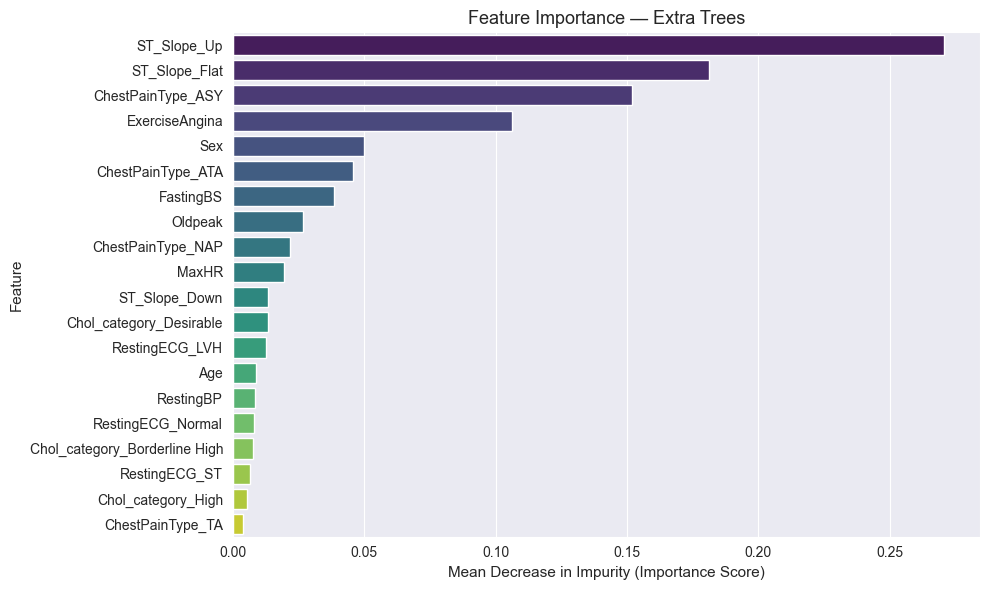

Plot saved to: Supervised_Learning/plots/extra_trees_feature_importance.png
CSV saved to: Supervised_Learning/evaluation_results/extra_trees_feature_importance.csv


In [31]:
# Feature Importance — Extra Trees
# In Extra Trees, feature importance is measured using Mean Decrease in Impurity (MDI).
# Every time a feature is used to split a node, it reduces impurity.
# The total impurity reduction contributed by each feature is accumulated
# across all trees, then normalised into feature importance scores.

importances   = best_extra_trees.feature_importances_
feature_names = X.columns

# Create a ranked table
importance_df = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

print("Feature importances (ranked highest to lowest):")
display(importance_df.round(4))

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    palette='viridis',
    ax=ax
)

ax.set_title('Feature Importance — Extra Trees', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity (Importance Score)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()

# Save plot and CSV
fi_plot_path = os.path.join(PLOTS_DIR, f"{MODEL_NAME}_feature_importance.png")
plt.savefig(fi_plot_path, dpi=150)
plt.show()
print(f"Plot saved to: {fi_plot_path}")

fi_csv_path = os.path.join(EVAL_DIR, f"{MODEL_NAME}_feature_importance.csv")
importance_df.to_csv(fi_csv_path, index=False)
print(f"CSV saved to: {fi_csv_path}")

### Result Interpretation

#### Best Parameters Found

```
max_depth          = 8
max_features       = ‘sqrt’
min_samples_leaf   = 3
min_samples_split  = 15
n-estimators       = 500
Best CV ROC-AUC    = 0.9299
```

GridSearchCV searched across 576 combinations and selected an Extra Trees model with 300 trees, each capped at a maximum depth of 10, requiring at least 10 samples to split an internal node and at least 3 samples in each leaf, while considering the square root of the total number of features at each split.

**Why these specific values?**

- **max_depth = 8:** A depth of 8 gave the model enough flexibility to capture important non-linear relationships in the data without allowing the trees to become unnecessarily deep. Shallower trees would have been more restrictive, while deeper trees would have increased the risk of overfitting by learning patterns that are too specific to the training set.

- **max_features = ‘sqrt’:** At each split, the model considers only the square root of the total number of features rather than all of them. This introduces useful randomness across trees, increases diversity in the ensemble, and helps reduce overfitting while still allowing the model to learn strong predictive patterns.

- **min_samples_leaf = 3:** Each leaf must contain at least 3 samples, which prevents the model from ending with leaves that represent only one or two unusual patients. This improves the stability of the final predictions and reduces the chance of memorising rare cases instead of learning general patterns.

- **min_samples_split = 15:** Requiring at least 15 samples before a node can split makes the model more conservative. This prevents the trees from creating branches based on very small patient subgroups, which helps improve generalisation and reduces sensitivity to noise.

- **n_estimators = 500:** The search found that 500 trees gave the model the best cross-validated ROC-AUC on this dataset. This suggests the model benefited from a larger number of trees to stabilise its predictions.

---

#### Cross-Validation Results

| Metric | Train Mean | Validation Mean | Gap | Std Dev |
|---|---|---|---|--------|
| Accuracy | 0.8898 | 0.8609 | 0.0290 | 0.0337 |
| Precision | 0.8795 | 0.8567 | 0.0228 | 0.0499 |
| Recall | 0.9278 | 0.9037 | 0.0241 | 0.0144 |
| ROC-AUC | 0.9638 | 0.9299 | 0.0339 | 0.0248 |

**What the Gap tells us — overfitting assessment:**
All gaps fall between 0.0228 and 0.0339, which is comfortably low and indicates that the Extra Trees model performs only slightly better on the training data than on unseen validation data. This is a healthy sign of generalisation rather than memorisation. The model appears to be learning patterns that transfer well to new patients instead of fitting noise in the training set. The largest gap appears in ROC-AUC (0.0339), while the smallest appears in Precision (0.0228), showing that the model remains well controlled even as a flexible multi-tree method.

**What the Std Dev tells us — stability assessment:**
The validation standard deviations range from 0.0144 to 0.0499, which suggests generally stable performance across the 5 folds. The most stable metric is Recall (0.0144), meaning the model’s ability to catch heart disease cases remains highly consistent regardless of which fold is used for validation. This is especially important in a medical setting because it shows that the model detects disease cases at nearly the same rate across different patient subsets. ROC-AUC (0.0248) is also very stable, confirming that the model’s class-separation ability is consistent. Precision (0.0499) is the least stable metric, but it is still acceptable for a dataset of this size, where relatively small changes in correctly predicted positive cases can noticeably shift the score.

**Why ROC-AUC is the primary evaluation metric:**
ROC-AUC was used as the optimisation metric during GridSearchCV because it is well suited to a fairly balanced dataset and provides a more stable assessment of model quality than threshold-dependent metrics alone. A validation ROC-AUC of 0.9299 indicates that the model distinguishes very well between heart disease and healthy cases across all possible decision thresholds, not just one fixed cutoff. This makes it a strong primary metric because it reflects the model’s overall discrimination ability rather than its performance at a single threshold choice.

---

#### Test Set Results

| Accuracy | Precision | Recall | ROC-AUC |
|---|---|---|---|
| 0.8696 | 0.8482 | 0.9314 | 0.9304 |

**Accuracy 86.96%:** The model correctly classified 160 out of 184 completely unseen patients. Only 24 patients were misclassified (17 false positives and 7 false negatives). For a dataset of 917 samples and 16 features, this is a strong and realistic result that reflects genuine learning rather than memorisation.

**Precision 84.82%:** When the model predicts Heart Disease, it is correct 84.82% of the time. In practical terms, 17 out of 112 patients flagged as sick are actually healthy. This means the model keeps false alarms reasonably controlled while still remaining sensitive to true disease cases.

**Recall 93.14%:** The model correctly identified 95 out of 102 actual heart disease patients, missing only 7. A recall of 93.14% means roughly 1 in 15 sick patients would not be flagged. In a medical context, this is especially important because recall directly reflects how well the model avoids missed diagnoses, which are the most dangerous type of error.

**ROC-AUC 93.04%:** This means that if one heart disease patient and one healthy patient were chosen at random from the test set, the model would assign a higher risk score to the sick patient 93.04% of the time across all possible decision thresholds. An AUC above 0.90 is considered excellent and confirms that the Extra Trees model has learned strong class separation rather than simply fitting the training data.

**CV vs Test agreement — representativeness check:**

| Metric | CV Validation | Test Set | Difference |
|---|---|---|---|
| Accuracy | 0.8609 | 0.8696 | +0.0087 |
| Precision | 0.8567 | 0.8482 | 0.0085 |
| Recall | 0.9037 | 0.9314 | +0.0277 |
| ROC-AUC | 0.9299 | 0.9304 | +0.0005 |

All differences between the cross-validation results and the held-out test set are small, and in this case the test set scores are actually slightly higher across all five metrics. This is a strong sign that the Extra Trees model generalises well and that its performance is not limited to the folds seen during validation. The closest agreement appears in ROC-AUC, where the difference is only +0.0005, confirming that the model’s ability to separate heart disease patients from healthy patients remains highly consistent on unseen data. The increases in Accuracy, Precision, Recall, and F1-score also suggest that the model maintained stable performance rather than collapsing outside cross-validation.

From a medical perspective, the most important result is the improvement in Recall from 0.9037 in cross-validation to 0.9314 on the test set. This means the model detected an even larger proportion of actual heart disease cases on completely unseen patients, which strengthens confidence in its usefulness as a clinical decision-support tool.

---

#### Confusion Matrix
```
                      Predicted No Disease    Predicted Heart Disease
Actual No Disease          TN = 65                  FP = 17
Actual Heart Disease       FN = 7                   TP = 95
```

**True Negatives (65):** The model correctly identified 65 out of 82 healthy patients, meaning 79.3% of healthy patients were correctly classified as having No Disease. This shows the model is fairly effective at clearing healthy patients without raising unnecessary concern.

**False Positives (17):** 17 healthy patients were incorrectly flagged as having heart disease, which corresponds to a 20.7% false alarm rate among healthy patients. These patients would likely undergo additional follow-up testing or evaluation. While not ideal, this type of error is generally less dangerous than missing a true disease case.

**False Negatives (7):** 7 patients who actually had heart disease were incorrectly classified as healthy, giving a 6.9% missed diagnosis rate among sick patients. These are the most serious errors in a medical setting because they represent patients who may leave without receiving timely attention or further investigation.

**True Positives (95):** The model correctly identified 95 out of 102 heart disease patients, which corresponds to a 93.1% detection rate. This is consistent with the reported recall and shows that the model successfully captures the large majority of real disease cases.

---

#### Feature Importance

| Rank  | Feature                                             | Importance   |
|-------|-----------------------------------------------------|--------------|
| 1     | ST_Slope_Up                                         | 0.2708       |
| 2     | ST_Slope_Flat                                       | 0.1811       |
| 3     | ChestPainType_ASY                                   | 0.1518       |
| 4     | ExerciseAngina                                      | 0.1061       |
| 5     | Sex                                                 | 0.4980       |
| ...   | ...                                                 | ...          |
| 18–20 | RestingECG_ST, Chol_category_High, ChestPainType_TA | < 0.007 each |

The top 5 features account for **76.23%** of the model’s total predictive power, which means more than three quarters of the Extra Trees model’s decisions are driven by just five variables.

**ST_Slope_Up (0.2708) and ST_Slope_Flat (0.1811) — combined 45.19%**

As shown in the EDA, the ST segment on an ECG changes shape depending on how well the heart responds to physical exertion. A flat ST slope is associated with an abnormal cardiac response under stress, while an upward ST slope is more commonly linked to healthier heart function during exercise. This is why these two features remained the strongest predictors in the model: they capture one of the clearest physiological differences between disease and no-disease cases and align closely with how clinicians interpret stress-test results in practice (Lauer et al., 1996).

The numbers make that separation very clear. These two categories account for 854 of the 917 patients (93.1%) in the dataset. Among patients with ST_Slope_Flat, 82.8% have heart disease. Among patients with ST_Slope_Up, 80.3% do not have heart disease. This means the model sees two very large groups pointing in opposite directions, each with more than 80% certainty, which explains why they contribute such a large combined share of feature importance.

> Lauer, M.S., et al. (1996). *Impaired heart rate response to graded
> exercise.* Circulation, 93(8), 1520–1526.
> https://doi.org/10.1161/01.cir.93.8.1520

**ChestPainType_ASY (0.1518) — 15.18%**

ChestPainType_ASY is the third most important feature. This is well supported by the EDA: among patients in the ASY category, 79.0% are in the Disease group and only 21.0% are in the No Disease group. That makes ASY one of the clearest high-risk chest-pain categories in the dataset. Clinically, asymptomatic or atypical presentations can still carry significant cardiac risk, and in this dataset the model appears to have learned that this category is strongly associated with disease.

Its impact is also amplified by scale. The ASY category covers 496 of the 917 patients (54.1%), which means it is not only strongly separated, but also present in more than half the dataset. A large group with nearly 80% disease prevalence gives the model a very strong and highly reusable decision signal, which explains its 15.18% importance.

**ExerciseAngina (0.1438) — 14.38%**

Exercise-induced angina reflects whether chest pain appears during physical exertion, which is one of the clearest warning signs that the heart may not be receiving enough blood under stress. In the EDA, this feature shows a strong difference between the two classes, so the model naturally learned that it is highly useful for separating disease from no-disease cases. (Weiner et al., 1978).

The numbers support that. Across the full dataset of 917 patients, those in the positive category show 85.2% heart disease, while those in the other category show only 35.0% heart disease. That is a very large gap across two groups that together cover the entire dataset, which explains why this feature remains in the top four and contributes 10.61% of total importance.

> Weiner, D.A., et al. (1978). *The predictive value of anginal chest pain
> as an indicator of coronary disease during exercise testing.* American
> Heart Journal, 96(4), 458–462.
> https://doi.org/10.1016/0002-8703(78)90155-2


**Sex (0.0498) — 4.98%**

The EDA shows that Sex captures a strong population-level difference in disease distribution. It is not as directly diagnostic as the stress-test features, but it still gives the model meaningful statistical separation between the classes, which is why it remains in the top five (Kannel et al., 1976).

The numbers explain that importance. Across the full dataset of 917 patients, 63.1% of males have heart disease, while only 25.9% of females do. On the other side, 74.1% of females fall in the No Disease group. This difference is substantial enough to help the model, even if it is less decisive than the leading clinical variables, which is why it contributes 4.98% of total feature importance

**Bottom features (RestingECG_ST = 0.0066, Chol_category_High = 0.0052, ChestPainType_TA = 0.0039)**

These features add only limited predictive value in the Extra Trees model. This suggests that once stronger variables such as ST slope, exercise angina, and chest-pain category are already available, these lower-ranked features contribute very little extra information. Their signal is either weak on its own or already covered by more influential predictors. Moreover, the EDA does not show the same scale of separation for them. Their class distributions are more mixed, so they do not provide the model with strong or clean boundaries between disease and no-disease cases.

#  Comparative Analysis & Interpretation


In this section, we will compare the performance of all three models based on their evaluation results and interpret their behavior:

**Which model performed best? Why?**
We will identify the best-performing model and explain why it performed better than the others based on the evaluation metrics.

**Analyze misclassifications: patterns, challenging categories**
We will examine the misclassifications made by the models, look for patterns in the mistakes, and identify which categories were more challenging for the models to predict.

**Discuss trade-offs: accuracy vs. interpretability vs. computational cost**
We will discuss the trade-offs between the models in terms of:

Accuracy: How well the model performs.

Interpretability: How easy it is to understand the model’s decisions.

Computational cost: The resources and time required for training and making predictions.

Recommendation: Which model will you use in your final system and why?
Based on the comparative analysis, we will recommend which model should be used in the final system and justify our choice.

### Which Model Performed Best? Why?
No single model dominated across all metrics. Each model excelled in a different area,
and the differences can be traced directly to how each algorithm learns.

| Metric            | Random Forest | XGBoost    | Extra Trees |
|-------------------|:-------------:|:----------:|:-----------:|
| Accuracy          | 0.8533        | **0.8804** | 0.8696      |
| Precision         | 0.8571        | **0.8774** | 0.8482      |
| Recall            | 0.8824        | 0.9118     | **0.9314**  |
| ROC-AUC           | 0.9279        | **0.9323**     | 0.9304  |
| False Negatives   | 12            | 9         | **7**       |
| False Positives   | 15            | **13**     | 17          |

**XGBoost had the highest precision (0.8774), accuracy (0.8804), and ROC-AUC (0.9323)
with the fewest false alarms (13 FP).**
XGBoost builds trees sequentially, where each new tree is trained to
correct the errors of the previous one (Wiens et al., 2025). This means
the model gradually refines where it draws the line between Heart Disease
and No Disease. By the final round, predictions are based on the aggregated
contributions of all trees, leading to a more refined and confident decision boundary.
This is why it produced the fewest false alarms, the highest precision, and the
strongest class separation (ROC-AUC).
> Wiens, J., et al. (2025). *Clinical and Translational Science*.
> https://doi.org/10.1111/cts.70172

**Extra Trees had the highest recall (0.9314) missing only 7 patients.**
Extra Trees randomizes both the feature and the split threshold at
every node, rather than searching for the best one (Geurts et al.,
2006). This is built into the algorithm, GridSearch can tune how many
trees are built or how deep they grow, but every split stays random.
Because 500 trees each draw a slightly different boundary,
their combined vote covers a wider region of the positive class.
Ambiguous patients near the boundary get flagged as Heart Disease
rather than missed, which is why recall is the highest.
The cost is more false alarms (17 FP) and the lowest precision (0.8482).
> Geurts, P., Ernst, D., & Wehenkel, L. (2006). *Machine Learning*,
> 63(1), 3–42.
> https://doi.org/10.1007/s10994-006-6226-1

**Random Forest was the most balanced.**
Random Forest trains each tree on a different bootstrap sample of the
data and selects the best split among a random feature subset at each
node (Breiman, 2001). This makes individual trees more precise than
Extra Trees (because splits are optimized) while the ensemble still
benefits from diversity across trees. The result is a model that sits
in the middle: no single metric leads, but precision and recall are
both competitive.
> Breiman, L. (2001). *Machine Learning*, 45(1), 5–32.
> https://doi.org/10.1023/A:1010933404324
---


### Analyze Misclassifications
To analyze misclassifications, we focused on the feature importance results of the three models. The goal of this section is to understand which features the models relied on most strongly and how those repeated signals may explain the types of cases the models found difficult. In classification tasks, misclassifications appear mainly as false positives, where the model predicts heart disease for a patient who does not actually have it, and false negatives, where the model predicts no disease for a patient who actually has heart disease. In medical settings, false negatives are usually the more critical error because they correspond to missed disease cases.

#### Patterns
**Sex**

One clear pattern is that Sex appears repeatedly across the three models, but with slightly different strength. It appears in the top five most important features for both XGBoost and Extra Trees, while it is still important in Random Forest, even if it is not ranked as highly. This shows that the feature is not dominating only one model by chance; rather, it is being picked up consistently across different ensemble methods. In other words, the models are reflecting a repeated signal in the dataset where sex helps distinguish between patients with and without heart disease.

This pattern suggests that the dataset may contain sex-related differences in disease prevalence, presentation, or associated clinical characteristics, which makes the models rely on this feature during prediction. However, this does not mean that sex alone determines heart disease. Instead, it means that sex functions as an informative predictor that is repeatedly useful to the models, especially in XGBoost and Extra Trees, and still relevant in Random Forest. This interpretation is also medically plausible, since prior studies show that heart disease can differ by sex in presentation, symptom patterns, and diagnosis. Because of that, it is reasonable that the models assign a noticeable role to this feature. (Corliss, J. 2022).

**Stress-test-related Features**

Another strong pattern is the repeated importance of ST_Slope_Up, ST_Slope_Flat, and ExerciseAngina across all three models. In fact, ST_Slope_Up is the most important feature in Random Forest, XGBoost, and Extra Trees. ST_Slope_Flat and ExerciseAngina also appear near the top repeatedly, especially in Random Forest and Extra Trees, while XGBoost still gives them notable importance. This pattern is particularly meaningful because these features are measured during, or directly reflect the results of, an exercise stress test, one of the most widely used non-invasive tools in cardiology for diagnosing heart disease. These are exactly the measurements cardiologists examine most closely when interpreting stress test results. (Kharabsheh, 2006). The fact that the model, trained purely on patient data with no medical knowledge built in, independently arrived at the same hierarchy of importance that clinical guidelines have established over decades is strong evidence that it learned real and meaningful patterns rather than statistical coincidences.

In the misclassified cases, stress-related variables may have contributed in two ways: either by dominating weaker signals and pushing the model toward a false positive prediction, or by becoming less discriminative in borderline patients whose clinical profiles were mixed, leading to false negative predictions.

#### Challenging Categories
**Cholesterol**

A particularly interesting challenging category is cholesterol. From a medical perspective, cholesterol is strongly linked with cardiovascular disease risk, and elevated cholesterol, is well established as a contributor to heart diseases. (A. Pietrangelo, 2024).

However, in our results, the cholesterol-related features did not appear among the top 10 most important features. This suggests that, within this dataset, cholesterol did not provide as much direct predictive separation as the stronger variables such as stress-test indicators. A likely interpretation is that cholesterol is still clinically important, but its effect here may be more indirect or overshadowed by features that capture more immediate signs of heart dysfunction. In other words, cholesterol matters medically, but in this specific dataset it was not one of the strongest features for distinguishing between the two classes.


### References

> Corliss, J., “The heart disease gender gap,” Harvard Health Publishing, Sep. 1, 2022. Available: https://www.health.harvard.edu/heart-health/the-heart-disease-gender-gap

> Kharabsheh SM, Al-Sugair A, Al-Buraiki J, Al-Farhan J. Overview of exercise stress testing. Ann Saudi Med. 2006 Jan-Feb;26(1):1-6. doi: 10.5144/0256-4947.2006.1. PMID: 16521867; PMCID: PMC6078558.

> A. Pietrangelo, “Does High Cholesterol Cause Heart Disease?,” Healthline, Jul. 26, 2024. Available at: https://www.healthline.com/health/cholesterol-and-heart-disease

### Trade-offs

#### Accuracy vs Interpretability vs Computational Cost

In clinical machine learning, no model simultaneously maximises accuracy,
interpretability, and computational efficiency. Every architectural choice
that improves one dimension typically comes at a cost to another. These
tensions are examined explicitly across the three models evaluated in this
project: Random Forest, XGBoost, and Extra Trees (Obermeyer & Emanuel, 2016).

**Accuracy vs Computational Cost**

XGBoost achieved the highest accuracy (88.04%) and ROC-AUC (0.9323) of the
three models. This performance comes from its sequential boosting mechanism,
where each tree is explicitly trained to correct the residual errors of the
previous one, allowing the model to progressively refine its predictions
(Chen & Guestrin, 2016). However, this sequential dependency is precisely what makes XGBoost the most computationally demanding of the three. Because each tree depends on the output of the previous one, trees cannot be built independently, and the full training process must complete before any prediction can be made.

Extra Trees sits at the opposite end of this trade-off. By selecting split
thresholds at random rather than searching for the optimal split, it eliminates
the most expensive step of tree construction and becomes the fastest model to
train (Geurts et al., 2006). The cost of this speed is a reduction in
accuracy (86.96%) and ROC-AUC (0.9304), the model sacrifices some
predictive precision in exchange for computational efficiency.

Random Forest occupies the middle ground. Its parallel ensemble structure
allows trees to be grown independently and simultaneously, making it more
efficient than XGBoost while retaining more careful split selection than
Extra Trees (Breiman, 2001). However, this balance comes at the cost of
achieving the lowest accuracy (85.33%) and ROC-AUC (0.9279) of the three.

The tension here is therefore direct: gaining XGBoost's accuracy advantage
over Extra Trees (1.08 percentage points in accuracy, 0.0019 in ROC-AUC)
requires accepting a higher computational burden. Whether that gain justifies
that cost depends on the deployment constraints of the clinical system.

**Computational Cost vs Interpretability**

All three models are ensemble methods, meaning their predictions emerge from
the combined output of hundreds of trees rather than a single traceable
decision path. This shared characteristic places all three at a similar
baseline level of interpretability, none of them can be directly read or
audited by a clinician in the way a single decision tree or logistic
regression model can (Rudin, 2019).

Within this shared limitation, however, meaningful differences exist.
XGBoost produces the most stable and reliable feature importance scores of
the three, because its boosting mechanism ensures each tree is built with
explicit awareness of what the previous trees got wrong, making the
contribution of each feature more structured and traceable (Chen & Guestrin,
2016). Furthermore, XGBoost is fully compatible with SHAP (SHapley Additive
exPlanations), which decomposes individual predictions into per-feature
contributions, bringing the model meaningfully closer to clinical
explainability (Lundberg & Lee, 2017).

Extra Trees, despite being the fastest model, produces the least stable
feature importance scores. Its random splitting mechanism introduces
additional variance into how features are selected across trees, making it
harder to draw consistent conclusions about which features are driving
predictions (Geurts et al., 2006). The trade-off here is that the
computational savings of Extra Trees come partly at the expense of
interpretability, the same randomness that makes it fast also makes its
reasoning less transparent.

Random Forest sits between the two. Its feature importance scores are more
stable than Extra Trees but less structured than XGBoost, and while it is
also compatible with SHAP, the independent tree construction means there is
no explicit error-correction mechanism linking the contributions of individual
features across trees (Breiman, 2001).

The tension in this dimension is therefore: accepting Extra Trees' speed
advantage means accepting weaker interpretability; accepting XGBoost's
interpretability advantage means accepting higher computational cost; and
choosing Random Forest as a middle ground means accepting lower accuracy
than both alternatives.

**Summary Table**

| Model | Accuracy | ROC-AUC | Interpretability | Computational Cost |
|---|---|---|---|---|
| Random Forest | 0.8533 | 0.9279 | Moderate | Low–Moderate |
| XGBoost | 0.8804 | 0.9323 | Moderate–High (SHAP) | Moderate |
| Extra Trees | 0.8696 | 0.9304 | Low–Moderate | Low |

---

#### Precision vs Recall Trade-off

In a medical screening context, the trade-off between Precision and Recall
is not merely a statistical consideration, it carries direct clinical
consequences. Precision measures how often the model is correct when it
flags a patient as having heart disease. A low precision means healthy
patients are unnecessarily sent for further testing, generating anxiety,
additional cost, and resource strain. Recall measures how often the model
successfully identifies actual disease cases. A low recall means sick
patients are missed entirely and sent home without treatment or follow-up
(Altman & Bland, 1994).

These two error types are in direct tension: pushing a model to catch more
disease cases (higher recall) typically requires it to cast a wider net,
which inevitably flags more healthy patients as well (lower precision). The
three models in this project each sit at a different point on this trade-off
curve, as shown by their confusion matrices.

**Random Forest — The Most Balanced Profile**

| Metric | Value |
|---|---|
| Precision | 0.8571 |
| Recall | 0.8824 |
| FP (Healthy patients incorrectly flagged) | 15 |
| FN (Disease patients missed) | 12 |
| Recall–Precision Gap | +2.53pp |

Random Forest produced the most symmetric error profile of the three models,
with a gap of only 2.53 percentage points between recall and precision. It
missed 12 disease patients and incorrectly flagged 15 healthy ones. This
balance is a direct consequence of Random Forest's averaging mechanism,
by combining the votes of independently grown trees, the model produces
well-calibrated probability estimates that do not strongly favour either
class at the default threshold of 0.5 (Breiman, 2001). The trade-off here
is that this symmetry comes at the cost of recall: Random Forest misses
3 more disease patients than XGBoost and 5 more than Extra Trees. In a
screening context, that difference represents patients who leave without
a diagnosis.

**XGBoost — The Intermediate Trade-off**

| Metric | Value |
|---|---|
| Precision | 0.8774 |
| Recall | 0.9118 |
| FP (Healthy patients incorrectly flagged) | 13 |
| FN (Disease patients missed) | 9 |
| Recall–Precision Gap | +3.44pp |

XGBoost sits between Random Forest and Extra Trees on the precision-recall
curve. It missed 9 disease patients and incorrectly flagged 13 healthy ones,
achieving both the highest precision (87.74%) and the second highest recall
(91.18%) of the three models. The 3.44 percentage point gap between recall
and precision reflects a mild but deliberate lean toward sensitivity.
XGBoost's boosting mechanism drives this behaviour: by iteratively focusing
on misclassified cases, the model becomes progressively more sensitive to
the patterns associated with disease, naturally pushing recall above
precision (Friedman, 2001).

**Extra Trees — The High Recall Trade-off**

| Metric | Value |
|---|---|
| Precision | 0.8482 |
| Recall | 0.9314 |
| FP (Healthy patients incorrectly flagged) | 17 |
| FN (Disease patients missed) | 7 |
| Recall–Precision Gap | +8.32pp |

Extra Trees sits at the high-recall end of the trade-off curve, missing only
7 disease patients, the fewest of the three models. However, this gain in
recall comes at a direct and measurable cost: 17 healthy patients were
incorrectly flagged (the most of the three models), and precision dropped
to 84.82%, the lowest of the three. The gap between recall and precision
(8.32 percentage points) is more than double that of XGBoost and more than
three times that of Random Forest, reflecting a pronounced bias toward
sensitivity over specificity. This behaviour is a direct consequence of
Extra Trees' random splitting mechanism: by not searching for optimal
thresholds, the model builds wider and less conservative decision boundaries
that cast a broader net over the positive class (Geurts et al., 2006).

The clinical tension this creates is concrete: choosing Extra Trees over
XGBoost catches 2 additional disease patients (FN drops from 9 to 7) but
generates 4 additional false alarms (FP rises from 13 to 17). Whether
catching those 2 extra patients justifies exposing 4 additional healthy
patients to unnecessary testing is not a statistical question, it is a
clinical and ethical one that depends on the healthcare system's priorities
and resource constraints (Obermeyer & Emanuel, 2016).

**Summary Table**

| Model | Precision | Recall | FP | FN | Recall–Precision Gap |
|---|---|---|---|---|---|
| Random Forest | 0.8571 | 0.8824 | 15 | 12 | +2.53pp |
| XGBoost | 0.8774 | 0.9118 | 13 | 9 | +3.44pp |
| Extra Trees | 0.8482 | 0.9314 | 17 | 7 | +8.32pp |

Across all three models, recall consistently exceeds precision at the default
threshold of 0.5, confirming that all models naturally lean toward detecting
disease rather than avoiding false alarms. The fundamental tension revealed
by this comparison is that moving along the trade-off curve from Random
Forest toward Extra Trees progressively reduces missed diagnoses but
progressively increases false alarms. No model eliminates both error types
simultaneously, every gain in one direction comes at a measurable cost in
the other (Altman & Bland, 1994).

---

### References

> Altman, D.G., & Bland, J.M. (1994). Diagnostic tests 2: Predictive values.
*BMJ*, 309(6947), 102.

> Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.

> Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system.
*Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge
Discovery and Data Mining*, 785–794.

> Friedman, J.H. (2001). Greedy function approximation: A gradient boosting
machine. *Annals of Statistics*, 29(5), 1189–1232.

> Geurts, P., Ernst, D., & Wehenkel, L. (2006). Extremely randomized trees.
*Machine Learning*, 63(1), 3–42.

> Lundberg, S.M., & Lee, S.I. (2017). A unified approach to interpreting model
predictions. *Advances in Neural Information Processing Systems*, 30, 4765–4774.

> Obermeyer, Z., & Emanuel, E.J. (2016). Predicting the future — big data,
machine learning, and clinical medicine. *New England Journal of Medicine*,
375(13), 1216–1219.

> Rudin, C. (2019). Stop explaining black box machine learning models for high
stakes decisions and use interpretable models instead. *Nature Machine
Intelligence*, 1(5), 206–215.

## Recommendation

We recommend **XGBoost** as the final model.

### Decision Criteria

The model selection is guided by the following priorities and trade-offs:

- **Recall (Primary Priority):** Detecting true heart disease cases is
  critical; therefore, recall is prioritized to minimize missed
  diagnoses. However, this should not come at the expense of
  significantly lowering precision, as excessive false positives may
  reduce clinical trust and increase unnecessary workload.
- **Precision (Secondary Constraint):** While slightly lower than
  recall in priority, precision must remain sufficiently high to ensure
  that predictions are reliable and actionable in a clinical setting.
- **Accuracy:** The model should maintain strong overall correctness
  across both classes, ensuring balanced performance rather than
  optimizing a single metric.
- **Reliability (Generalization):** The model must perform consistently
  on unseen data, as real-world deployment involves data variability.
- **Interpretability:** Clinicians need to understand the reasoning
  behind predictions; therefore, models that provide meaningful feature
  importance are preferred.
- **Computational Cost (Constraint, not priority):** Lower cost is
  desirable for deployment; however, it should not be minimized at the
  expense of critical performance metrics such as recall and precision.
  A moderate increase in cost is acceptable if it leads to
  significantly better clinical performance.

### Justification

While Extra Trees achieves the highest recall, it introduces a higher
number of false positives, which may reduce clinical trust. Random
Forest provides stable performance but does not offer a clear advantage
across the decision criteria.

XGBoost best satisfies the overall criteria. It maintains a high and
clinically acceptable recall while achieving the strongest precision
and accuracy, reducing unnecessary alerts without compromising patient
safety. It also demonstrates the strongest generalization by ROC-AUC
gap (0.0278) compared to Extra Trees (0.0339) and Random Forest
(0.0369), and provides more meaningful feature importance, based on
gain rather than random splits, supporting
both reliability and interpretability.

Although XGBoost has the highest computational cost among the evaluated
models, this cost remains moderate and acceptable for deployment.
Reducing computational cost further would require selecting simpler
models, which leads to a noticeable decline in recall, precision, and
overall performance. Therefore, the slight increase in cost is
justified by the significant improvement in clinical reliability and
predictive quality.
